In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette for models
MODEL_COLORS = {
    'MobileNet': '#e74c3c',
    'EfficientNet-B2': '#3498db',
    'EfficientNet-B3': '#2ecc71',
    'EfficientNet-B5': '#9b59b6'
}

CLASS_COLORS = plt.cm.Set2(np.linspace(0, 1, 8))

print("✅ Libraries loaded and configuration set.")

# %% [markdown]
# ## 1. Data Loading & Structuring

# %%
class_names = [
    "double_plant", "drydown", "endrow", "nutrient_deficiency",
    "waterway", "water", "planter_skip", "weed_cluster"
]

# --- MobileNet ---
mobilenet_training = {
    'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    'train_loss': [0.2724, 0.0920, 0.0792, 0.0709, 0.0644, 0.0592, 0.0549, 0.0513, 0.0490, 0.0475, 0.0616, 0.0599, 0.0577, 0.0556],
    'val_loss': [0.1114, 0.1207, 0.0954, 0.0869, 0.0830, 0.0823, 0.0813, 0.0855, 0.0817, 0.0807, 0.0948, 0.0872, 0.0825, 0.0834],
    'val_miou': [0.3253, 0.3188, 0.3608, 0.3677, 0.3884, 0.3947, 0.3963, 0.3864, 0.3959, 0.3994, 0.3719, 0.3721, 0.3858, 0.3939],
    'learning_rate': [9.76e-05, 9.05e-05, 7.96e-05, 6.58e-05, 5.05e-05, 3.52e-05, 2.14e-05, 1.05e-05, 3.42e-06, 1.00e-04, 9.94e-05, 9.76e-05, 9.46e-05, 9.05e-05],
    'patience': [0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 1, 2, 3, 4],
    'best_model': [True, False, True, True, True, True, True, False, False, True, False, False, False, False]
}
mobilenet_class_iou = np.array([
    [0.2409, 0.3611, 0.1796, 0.3439, 0.1572, 0.6293, 0.4227, 0.2677],
    [0.2512, 0.2889, 0.2139, 0.3002, 0.1374, 0.6348, 0.4039, 0.3197],
    [0.2799, 0.4747, 0.2483, 0.3362, 0.2018, 0.6308, 0.4149, 0.2998],
    [0.2978, 0.5063, 0.2178, 0.3438, 0.2602, 0.6417, 0.3548, 0.3189],
    [0.3045, 0.5121, 0.2473, 0.3680, 0.2199, 0.6916, 0.4296, 0.3345],
    [0.3015, 0.5266, 0.2627, 0.3843, 0.2551, 0.6813, 0.4101, 0.3362],
    [0.3199, 0.5243, 0.2516, 0.3792, 0.2418, 0.6979, 0.4204, 0.3353],
    [0.3014, 0.5121, 0.2465, 0.3715, 0.2256, 0.7004, 0.4064, 0.3278],
    [0.3185, 0.5139, 0.2564, 0.3864, 0.2605, 0.6984, 0.3979, 0.3349],
    [0.3249, 0.5250, 0.2527, 0.3852, 0.2562, 0.7028, 0.4185, 0.3296],
    [0.3023, 0.4667, 0.2363, 0.3279, 0.2205, 0.6931, 0.4084, 0.3200],
    [0.2790, 0.4696, 0.2456, 0.3680, 0.2410, 0.6679, 0.4246, 0.2808],
    [0.2765, 0.5223, 0.2490, 0.3733, 0.2306, 0.6770, 0.4282, 0.3296],
    [0.3185, 0.5160, 0.2392, 0.3564, 0.2391, 0.6979, 0.4745, 0.3095],
])

# --- EfficientNet-B2 ---
effb2_training = {
    "epoch": list(range(1, 14)),
    "train_loss": [0.2062, 0.0823, 0.0723, 0.0659, 0.0620, 0.0588, 0.0563, 0.0541, 0.0525, 0.0509, 0.0492, 0.0478, 0.0465],
    "val_loss": [0.1134, 0.0963, 0.0913, 0.0934, 0.0885, 0.0912, 0.0948, 0.0922, 0.0838, 0.0803, 0.0777, 0.0773, 0.0756],
    "val_miou": [0.3116, 0.3715, 0.3709, 0.3884, 0.3911, 0.3873, 0.3718, 0.3832, 0.4012, 0.4033, 0.4134, 0.4150, 0.4252],
    "learning_rate": [9.99e-05, 9.96e-05, 9.91e-05, 9.84e-05, 9.76e-05, 9.63e-05, 9.48e-05, 9.30e-05, 9.11e-05, 8.85e-05, 8.57e-05, 8.27e-05, 7.95e-05],
    "patience": [0, 0, 1, 0, 0, 1, 2, 3, 0, 0, 0, 0, 0],
    "best_model": [True, True, False, True, True, False, False, False, True, True, True, True, True]
}
effb2_class_iou = np.array([
    [0.2949, 0.3416, 0.2512, 0.2942, 0.2283, 0.5907, 0.2874, 0.2043],
    [0.3065, 0.4621, 0.2528, 0.3274, 0.2181, 0.6853, 0.4125, 0.3074],
    [0.3147, 0.4760, 0.2424, 0.3351, 0.2345, 0.6871, 0.3629, 0.3143],
    [0.3322, 0.4636, 0.2655, 0.3752, 0.2459, 0.7016, 0.4500, 0.2729],
    [0.3221, 0.4935, 0.2725, 0.3430, 0.2305, 0.6758, 0.4543, 0.3368],
    [0.3410, 0.5249, 0.2631, 0.3586, 0.2312, 0.7083, 0.4007, 0.2712],
    [0.3338, 0.4806, 0.2496, 0.3813, 0.2169, 0.6798, 0.3589, 0.2733],
    [0.3439, 0.4928, 0.2439, 0.3966, 0.2195, 0.6992, 0.3839, 0.2857],
    [0.3412, 0.5292, 0.2743, 0.4173, 0.2656, 0.6629, 0.4127, 0.3066],
    [0.3538, 0.5287, 0.2931, 0.3930, 0.2227, 0.6884, 0.4229, 0.3239],
    [0.3494, 0.5390, 0.2791, 0.4085, 0.2514, 0.6793, 0.4774, 0.3226],
    [0.3591, 0.5512, 0.2969, 0.4127, 0.2265, 0.7116, 0.4271, 0.3348],
    [0.3537, 0.5670, 0.2864, 0.4107, 0.2531, 0.7194, 0.4742, 0.3368],
])

# --- EfficientNet-B3 ---
effb3_training = {
    'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    'train_loss': [0.2248, 0.0842, 0.0741, 0.0671, 0.0614, 0.0567, 0.0524, 0.0493, 0.0470, 0.0461, 0.0453, 0.0448, 0.0443],
    'val_loss': [0.1029, 0.1023, 0.0942, 0.0877, 0.0925, 0.0880, 0.0789, 0.0724, 0.0744, 0.0748, 0.0774, 0.0756, 0.0773],
    'val_miou': [0.3304, 0.3451, 0.3576, 0.3885, 0.3749, 0.3934, 0.4080, 0.4285, 0.4232, 0.4241, 0.4203, 0.4243, 0.4171],
    'learning_rate': [9.76e-05, 9.05e-05, 7.96e-05, 6.58e-05, 5.05e-05, 3.52e-05, 2.14e-05, 1.05e-05, 1.04e-05, 1.04e-05, 1.03e-05, 1.02e-05, 1.01e-05],
    'patience': [0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 3, 4, 5],
    'best_model': [True, True, True, True, False, True, True, True, False, False, False, False, False]
}
effb3_class_iou = np.array([
    [0.3072, 0.4606, 0.2310, 0.3253, 0.2181, 0.6221, 0.2171, 0.2621],
    [0.2968, 0.4338, 0.2647, 0.3490, 0.2148, 0.5902, 0.3274, 0.2837],
    [0.3194, 0.4435, 0.2813, 0.3712, 0.2302, 0.6744, 0.2442, 0.2961],
    [0.3074, 0.4857, 0.2908, 0.3779, 0.2260, 0.6853, 0.4324, 0.3020],
    [0.3369, 0.4520, 0.2921, 0.3522, 0.2448, 0.6503, 0.3659, 0.3053],
    [0.3467, 0.4974, 0.2683, 0.3860, 0.2194, 0.6804, 0.4659, 0.2831],
    [0.3589, 0.5338, 0.2969, 0.3948, 0.2681, 0.6997, 0.3846, 0.3266],
    [0.3604, 0.5717, 0.3041, 0.4081, 0.2627, 0.7215, 0.4609, 0.3387],
    [0.3608, 0.5458, 0.3017, 0.4166, 0.2714, 0.7230, 0.4333, 0.3332],
    [0.3628, 0.5458, 0.3018, 0.4173, 0.2577, 0.7221, 0.4557, 0.3297],
    [0.3635, 0.5399, 0.3070, 0.4161, 0.2584, 0.7240, 0.4271, 0.3261],
    [0.3595, 0.5530, 0.3025, 0.4172, 0.2629, 0.7147, 0.4505, 0.3340],
    [0.3572, 0.5360, 0.3032, 0.4219, 0.2330, 0.7203, 0.4433, 0.3220],
])

# --- EfficientNet-B5 ---
effb5_training = {
    "epoch": [1,2,3,4,5,6,7,8,9,10,11,12,13],
    "train_loss": [0.2473, 0.1220, 0.0866, 0.0797, 0.0748, 0.0715, 0.0692, 0.0665, 0.0641, 0.0621, 0.0599, 0.0583, 0.0567],
    "val_loss": [0.1868, 0.1161, 0.0970, 0.1166, 0.0932, 0.0953, 0.1002, 0.0974, 0.0837, 0.0947, 0.0956, 0.1033, 0.0900],
    "val_miou": [0.2387, 0.3078, 0.3308, 0.3158, 0.3521, 0.3447, 0.3458, 0.3539, 0.3622, 0.3608, 0.3646, 0.3601, 0.3819],
    "learning_rate": [9.99e-05, 9.96e-05, 9.91e-05, 9.84e-05, 9.74e-05, 9.62e-05, 9.48e-05, 9.32e-05, 9.10e-05, 8.84e-05, 8.56e-05, 8.26e-05, 7.94e-05],
    "patience": [0,0,0,1,0,1,2,0,0,1,0,1,0],
    "best_model": [True, True, True, False, True, False, False, True, True, False, True, False, True]
}
effb5_class_iou = np.array([
    [0.2559, 0.2000, 0.0075, 0.3044, 0.1940, 0.4541, 0.2306, 0.2630],
    [0.2580, 0.3597, 0.2542, 0.2886, 0.2123, 0.5766, 0.3004, 0.2129],
    [0.2627, 0.4799, 0.2729, 0.3700, 0.2033, 0.5863, 0.2327, 0.2383],
    [0.2816, 0.2337, 0.2782, 0.2993, 0.2307, 0.5831, 0.3390, 0.2803],
    [0.2889, 0.4910, 0.2920, 0.3325, 0.2352, 0.5782, 0.3063, 0.2928],
    [0.2909, 0.3173, 0.2755, 0.3823, 0.2467, 0.6448, 0.3054, 0.2946],
    [0.3051, 0.4256, 0.2933, 0.3268, 0.2201, 0.5993, 0.3183, 0.2775],
    [0.2655, 0.5013, 0.2889, 0.3488, 0.1859, 0.5486, 0.4054, 0.2872],
    [0.3137, 0.5446, 0.2558, 0.4033, 0.2137, 0.5257, 0.3325, 0.3079],
    [0.3036, 0.4052, 0.3004, 0.3727, 0.1975, 0.6769, 0.3620, 0.2685],
    [0.3134, 0.4235, 0.2772, 0.3539, 0.2032, 0.6818, 0.3744, 0.2896],
    [0.3270, 0.3354, 0.2704, 0.3694, 0.1887, 0.6972, 0.4223, 0.2704],
    [0.3100, 0.5189, 0.2541, 0.3986, 0.2447, 0.6379, 0.4050, 0.2863],
])

# Build DataFrames
models = {
    'MobileNet': (mobilenet_training, mobilenet_class_iou),
    'EfficientNet-B2': (effb2_training, effb2_class_iou),
    'EfficientNet-B3': (effb3_training, effb3_class_iou),
    'EfficientNet-B5': (effb5_training, effb5_class_iou),
}

dfs = {}
for name, (td, ciou) in models.items():
    df = pd.DataFrame(td)
    for i, cn in enumerate(class_names):
        df[f'iou_{cn}'] = ciou[:, i]
    df['model'] = name
    dfs[name] = df

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"✅ Combined DataFrame: {df_all.shape[0]} rows × {df_all.shape[1]} columns")
print(f"   Models: {df_all['model'].unique().tolist()}")
print(f"   Classes: {class_names}")

# %%
# Quick overview of each model's training summary
summary_rows = []
for name, df in dfs.items():
    best_epoch = df.loc[df['val_miou'].idxmax()]
    summary_rows.append({
        'Model': name,
        'Total Epochs': len(df),
        'Best Epoch': int(best_epoch['epoch']),
        'Best mIoU': best_epoch['val_miou'],
        'Final Train Loss': df['train_loss'].iloc[-1],
        'Best Val Loss': df['val_loss'].min(),
        'Final Val Loss': df['val_loss'].iloc[-1],
        'mIoU Improvement': df['val_miou'].iloc[-1] - df['val_miou'].iloc[0],
        'Convergence (epoch to 95% best)': int(df[df['val_miou'] >= 0.95 * df['val_miou'].max()]['epoch'].iloc[0]),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*90)
print("MODEL TRAINING SUMMARY")
print("="*90)
display(summary_df.style.highlight_max(
    subset=['Best mIoU'], color='#a8e6cf'
).highlight_min(
    subset=['Best Val Loss', 'Final Train Loss'], color='#a8e6cf'
).format({
    'Best mIoU': '{:.4f}',
    'Final Train Loss': '{:.4f}',
    'Best Val Loss': '{:.4f}',
    'Final Val Loss': '{:.4f}',
    'mIoU Improvement': '{:+.4f}'
}))

✅ Libraries loaded and configuration set.
✅ Combined DataFrame: 53 rows × 16 columns
   Models: ['MobileNet', 'EfficientNet-B2', 'EfficientNet-B3', 'EfficientNet-B5']
   Classes: ['double_plant', 'drydown', 'endrow', 'nutrient_deficiency', 'waterway', 'water', 'planter_skip', 'weed_cluster']

MODEL TRAINING SUMMARY


,Model,Total Epochs,Best Epoch,Best mIoU,Final Train Loss,Best Val Loss,Final Val Loss,mIoU Improvement,Convergence (epoch to 95% best)
0,MobileNet,14,10,0.3994,0.0556,0.0807,0.0834,+0.0686,5
1,EfficientNet-B2,13,13,0.4252,0.0465,0.0756,0.0756,+0.1136,11
2,EfficientNet-B3,13,8,0.4285,0.0443,0.0724,0.0773,+0.0867,7
3,EfficientNet-B5,13,13,0.3819,0.0567,0.0837,0.0900,+0.1432,11


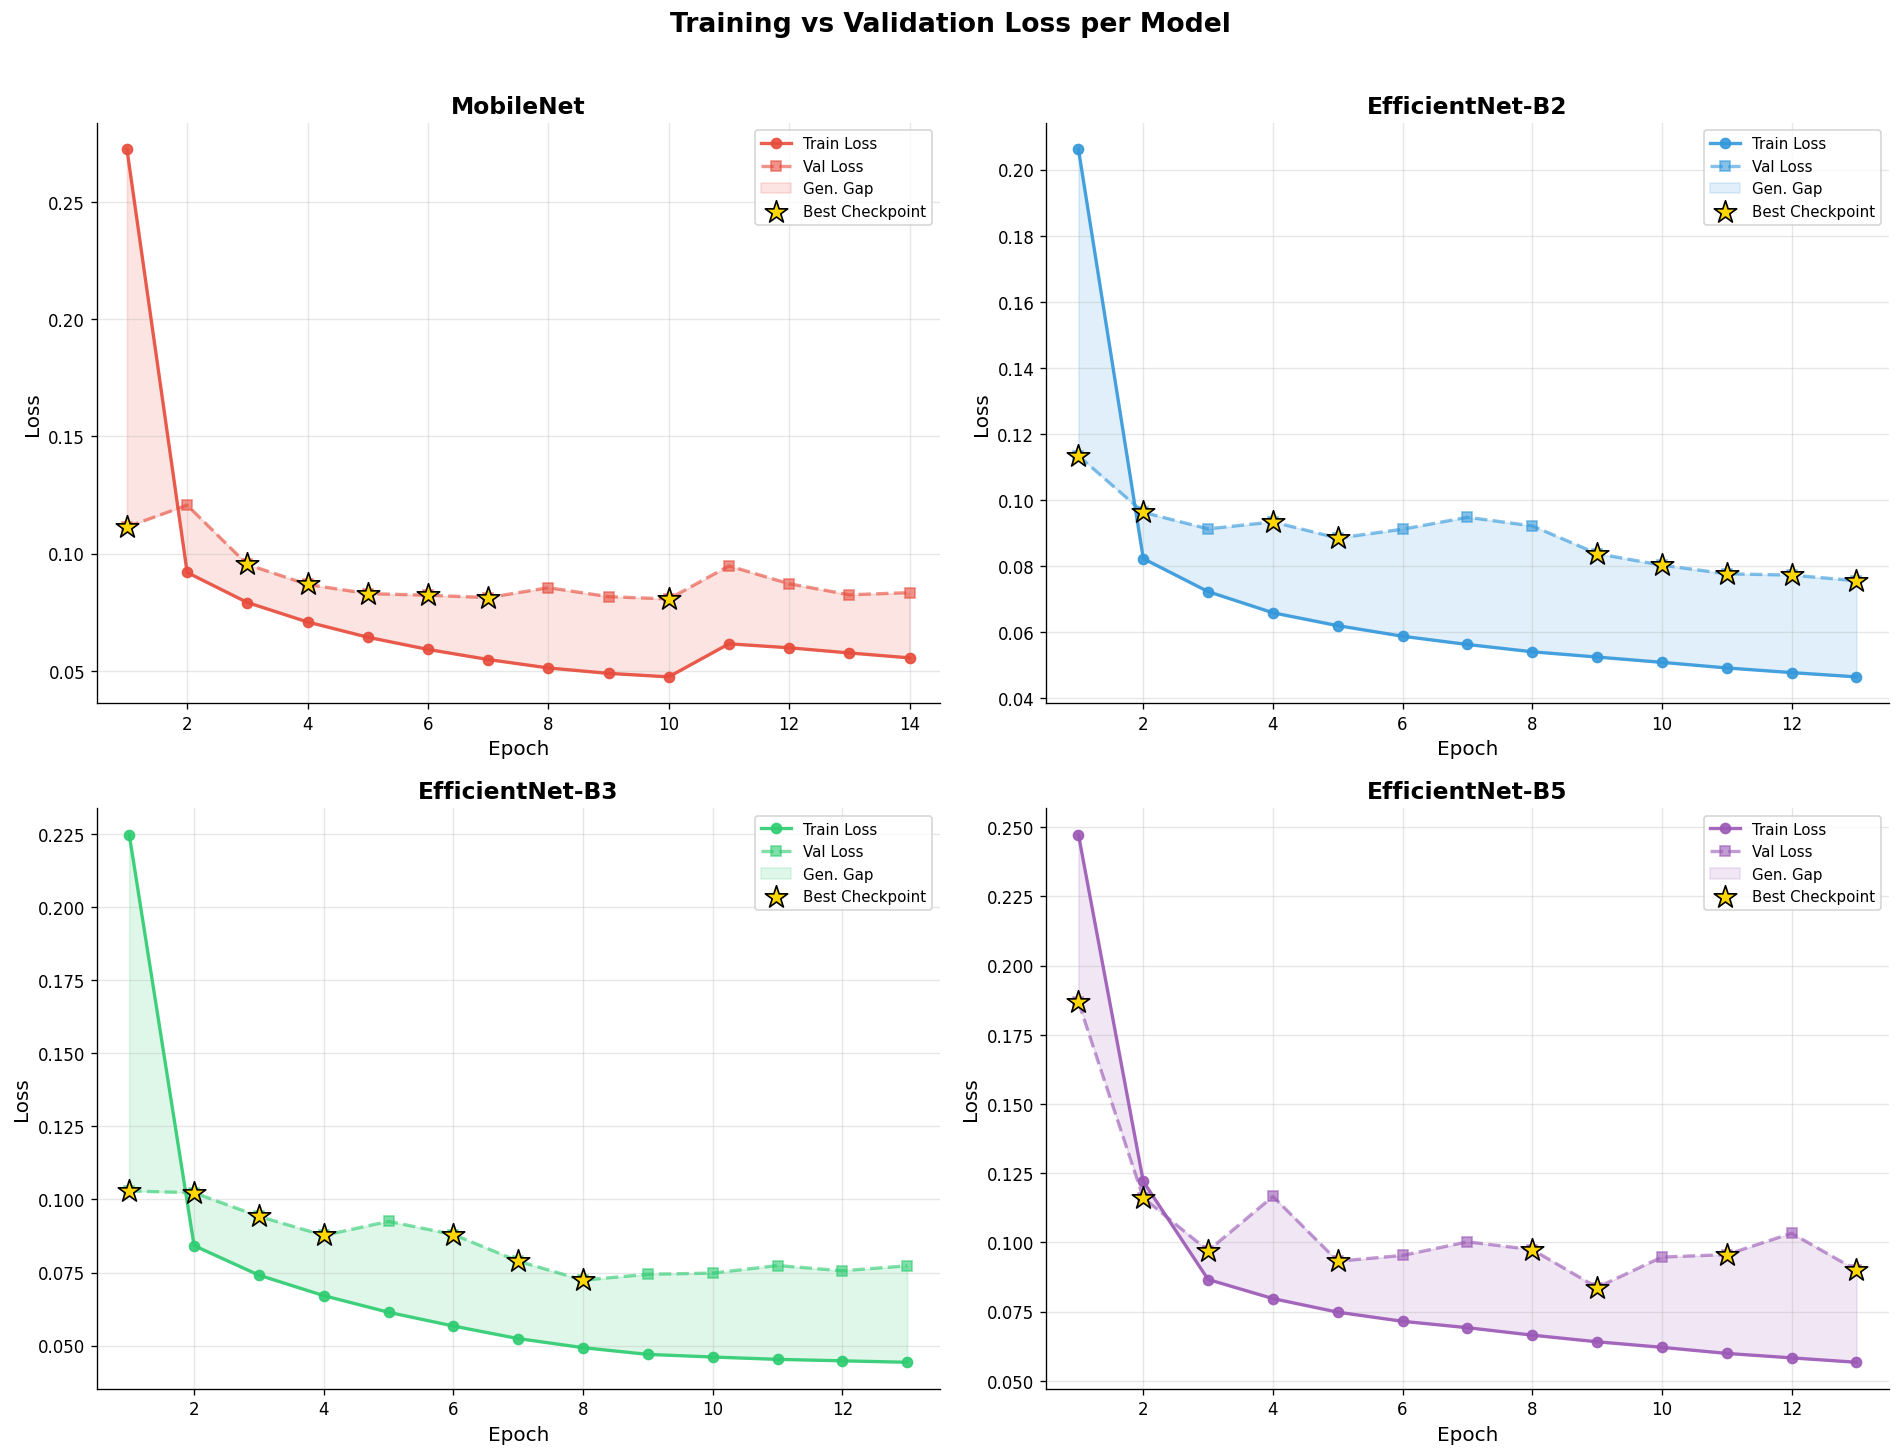

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (name, df) in enumerate(dfs.items()):
    ax = axes[idx // 2, idx % 2]
    color = MODEL_COLORS[name]

    ax.plot(df['epoch'], df['train_loss'], 'o-', color=color, linewidth=2,
            markersize=6, label='Train Loss', alpha=0.9)
    ax.plot(df['epoch'], df['val_loss'], 's--', color=color, linewidth=2,
            markersize=6, label='Val Loss', alpha=0.6)

    # Shade the generalization gap
    ax.fill_between(df['epoch'], df['train_loss'], df['val_loss'],
                     alpha=0.15, color=color, label='Gen. Gap')

    # Mark best model checkpoints
    best_epochs = df[df['best_model'] == True]
    ax.scatter(best_epochs['epoch'], best_epochs['val_loss'],
               marker='*', s=200, c='gold', edgecolors='black',
               zorder=5, label='Best Checkpoint')

    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0.5, df['epoch'].max() + 0.5)

fig.suptitle('Training vs Validation Loss per Model', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

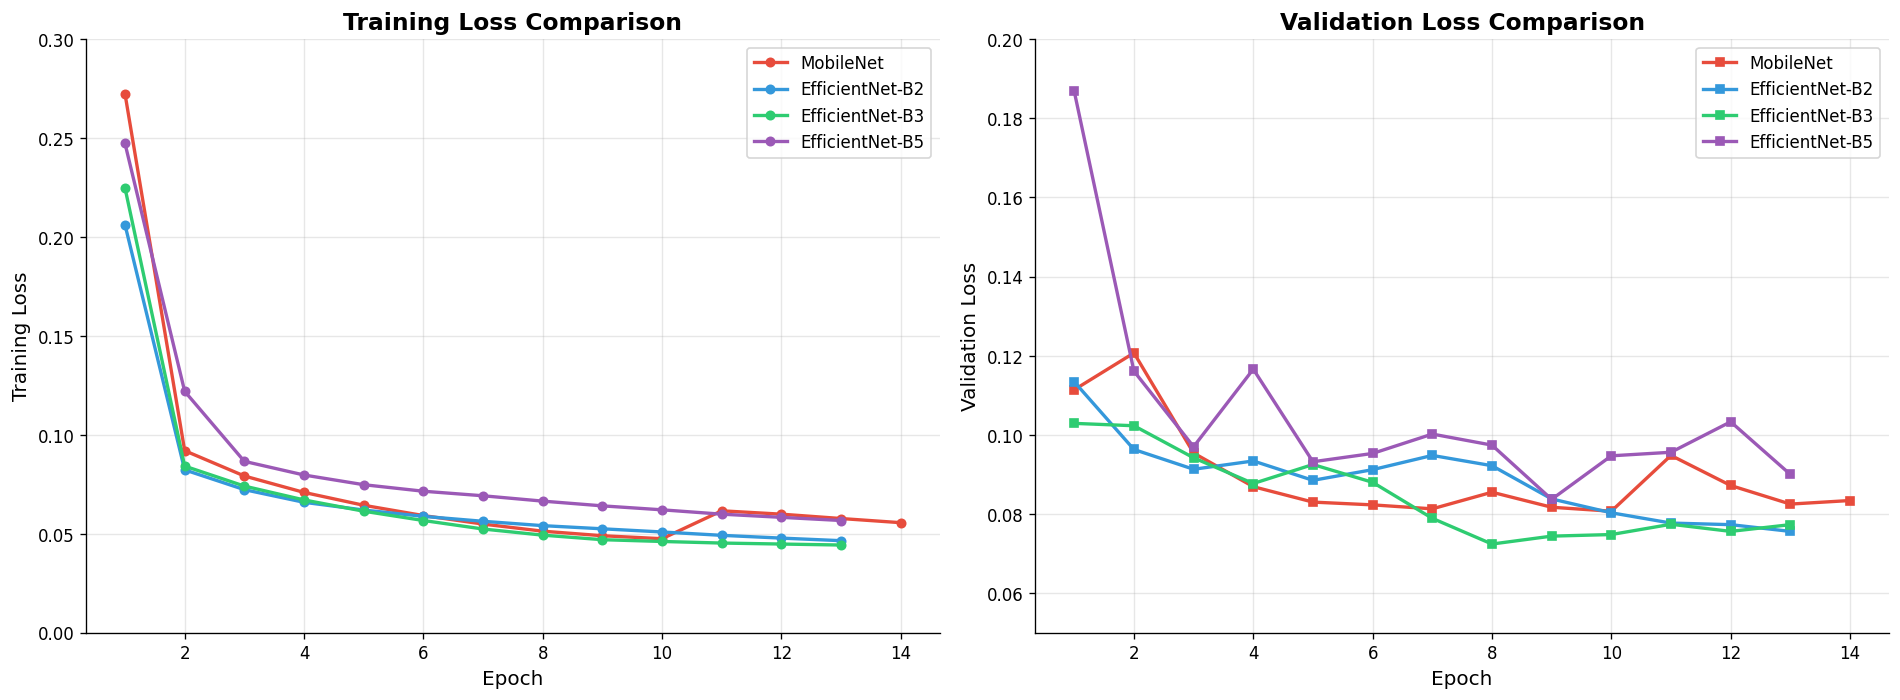

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, df in dfs.items():
    c = MODEL_COLORS[name]
    ax1.plot(df['epoch'], df['train_loss'], 'o-', color=c, linewidth=2,
             markersize=5, label=name)
    ax2.plot(df['epoch'], df['val_loss'], 's-', color=c, linewidth=2,
             markersize=5, label=name)

ax1.set_title('Training Loss Comparison', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.legend()
ax1.set_ylim(0, 0.30)

ax2.set_title('Validation Loss Comparison', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss')
ax2.legend()
ax2.set_ylim(0.05, 0.20)

plt.tight_layout()
plt.show()

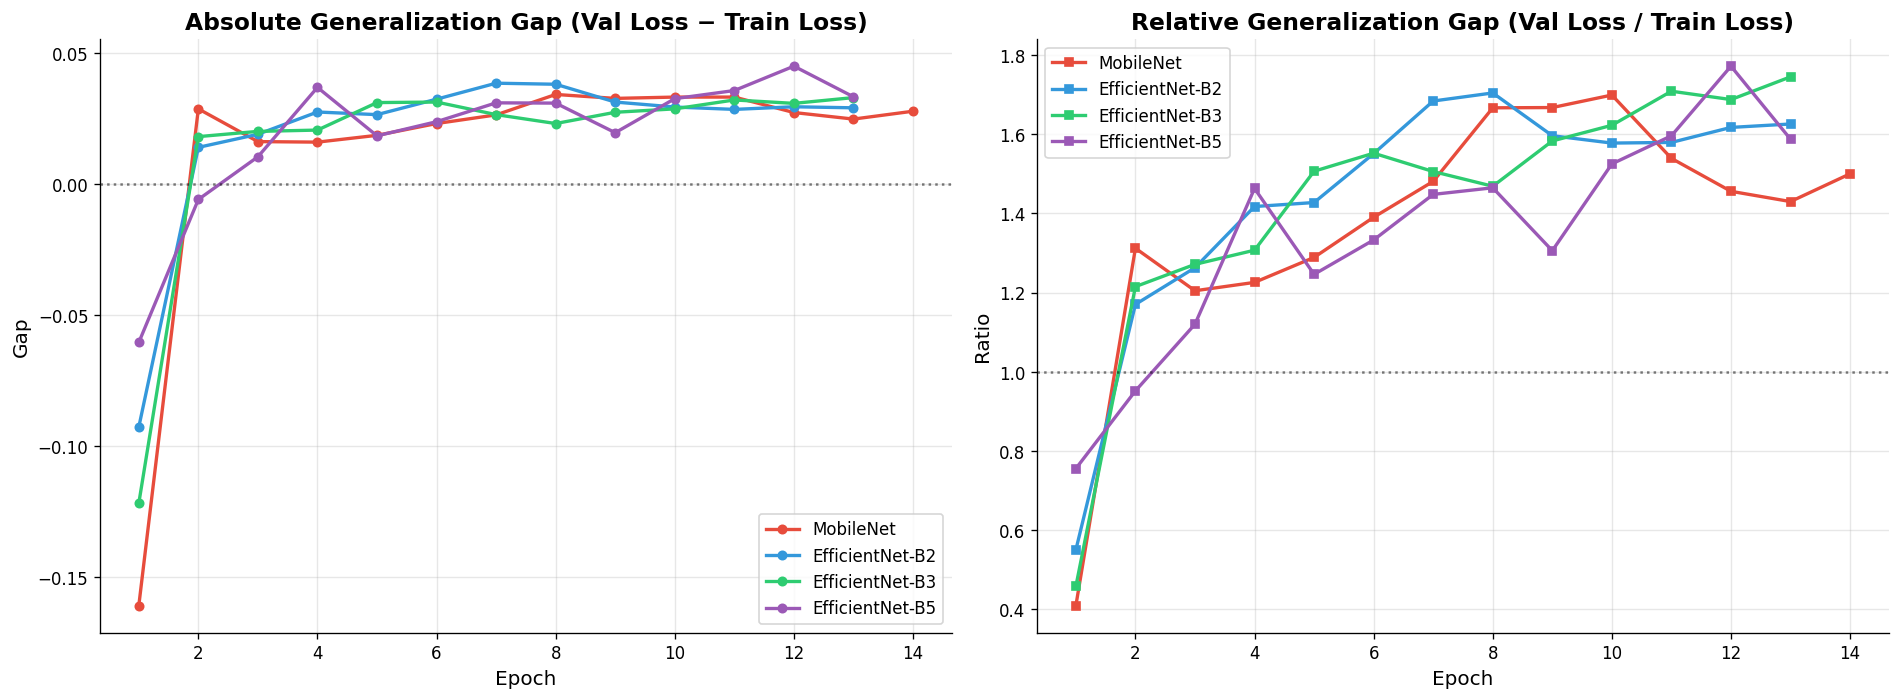


OVERFITTING ANALYSIS

MobileNet:
  Initial gap: -0.1610 → Final gap: 0.0278
  Final val/train ratio: 1.50x
  ⚡ Moderate overfitting

EfficientNet-B2:
  Initial gap: -0.0928 → Final gap: 0.0291
  Final val/train ratio: 1.63x
  ⚡ Moderate overfitting

EfficientNet-B3:
  Initial gap: -0.1219 → Final gap: 0.0330
  Final val/train ratio: 1.74x
  ⚡ Moderate overfitting

EfficientNet-B5:
  Initial gap: -0.0605 → Final gap: 0.0333
  Final val/train ratio: 1.59x
  ⚡ Moderate overfitting


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, df in dfs.items():
    c = MODEL_COLORS[name]
    gap = df['val_loss'] - df['train_loss']
    ax1.plot(df['epoch'], gap, 'o-', color=c, linewidth=2, markersize=5, label=name)

    # Relative gap (val_loss / train_loss)
    rel_gap = df['val_loss'] / df['train_loss']
    ax2.plot(df['epoch'], rel_gap, 's-', color=c, linewidth=2, markersize=5, label=name)

ax1.axhline(y=0, color='black', linestyle=':', alpha=0.5)
ax1.set_title('Absolute Generalization Gap (Val Loss − Train Loss)', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Gap')
ax1.legend()

ax2.axhline(y=1, color='black', linestyle=':', alpha=0.5)
ax2.set_title('Relative Generalization Gap (Val Loss / Train Loss)', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Ratio')
ax2.legend()

plt.tight_layout()
plt.show()

# Print overfitting analysis
print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)
for name, df in dfs.items():
    gap_start = df['val_loss'].iloc[0] - df['train_loss'].iloc[0]
    gap_end = df['val_loss'].iloc[-1] - df['train_loss'].iloc[-1]
    ratio_end = df['val_loss'].iloc[-1] / df['train_loss'].iloc[-1]
    print(f"\n{name}:")
    print(f"  Initial gap: {gap_start:.4f} → Final gap: {gap_end:.4f}")
    print(f"  Final val/train ratio: {ratio_end:.2f}x")
    if ratio_end > 1.8:
        print(f"  ⚠️  Significant overfitting detected")
    elif ratio_end > 1.5:
        print(f"  ⚡ Moderate overfitting")
    else:
        print(f"  ✅ Acceptable generalization")

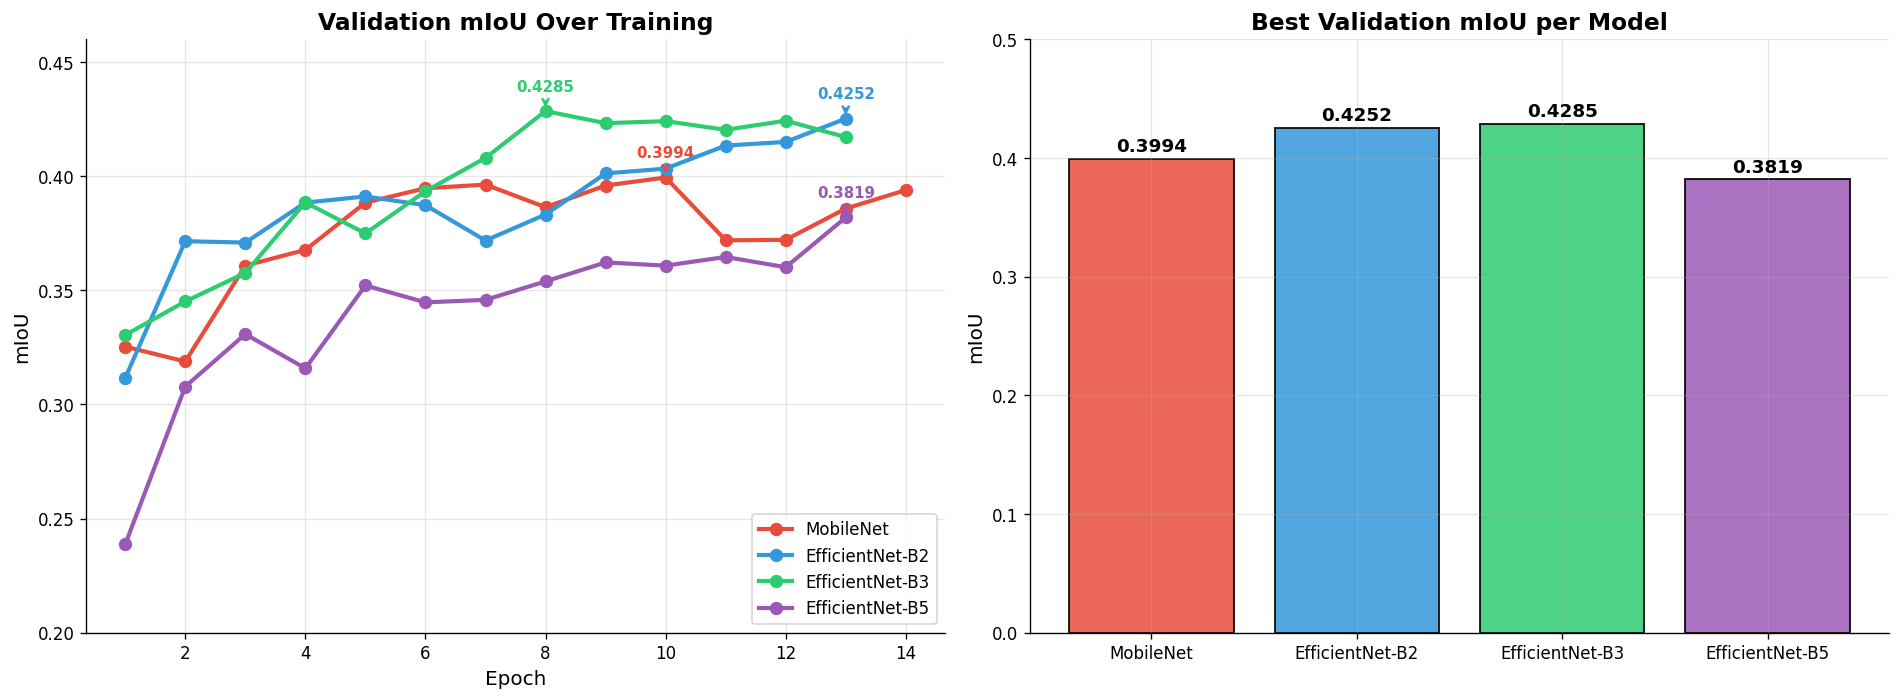

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# mIoU over epochs
ax = axes[0]
for name, df in dfs.items():
    c = MODEL_COLORS[name]
    ax.plot(df['epoch'], df['val_miou'], 'o-', color=c, linewidth=2.5,
            markersize=7, label=name)
    # Mark peak
    best_idx = df['val_miou'].idxmax()
    ax.annotate(f"{df.loc[best_idx, 'val_miou']:.4f}",
                xy=(df.loc[best_idx, 'epoch'], df.loc[best_idx, 'val_miou']),
                xytext=(0, 12), textcoords='offset points',
                fontsize=9, fontweight='bold', color=c,
                ha='center',
                arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

ax.set_title('Validation mIoU Over Training', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('mIoU')
ax.legend(loc='lower right')
ax.set_ylim(0.2, 0.46)

# Best mIoU bar chart
ax = axes[1]
best_mious = {name: df['val_miou'].max() for name, df in dfs.items()}
bars = ax.bar(best_mious.keys(), best_mious.values(),
              color=[MODEL_COLORS[n] for n in best_mious.keys()],
              edgecolor='black', linewidth=1.2, alpha=0.85)

for bar, val in zip(bars, best_mious.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Best Validation mIoU per Model', fontweight='bold')
ax.set_ylabel('mIoU')
ax.set_ylim(0, 0.50)

plt.tight_layout()
plt.show()

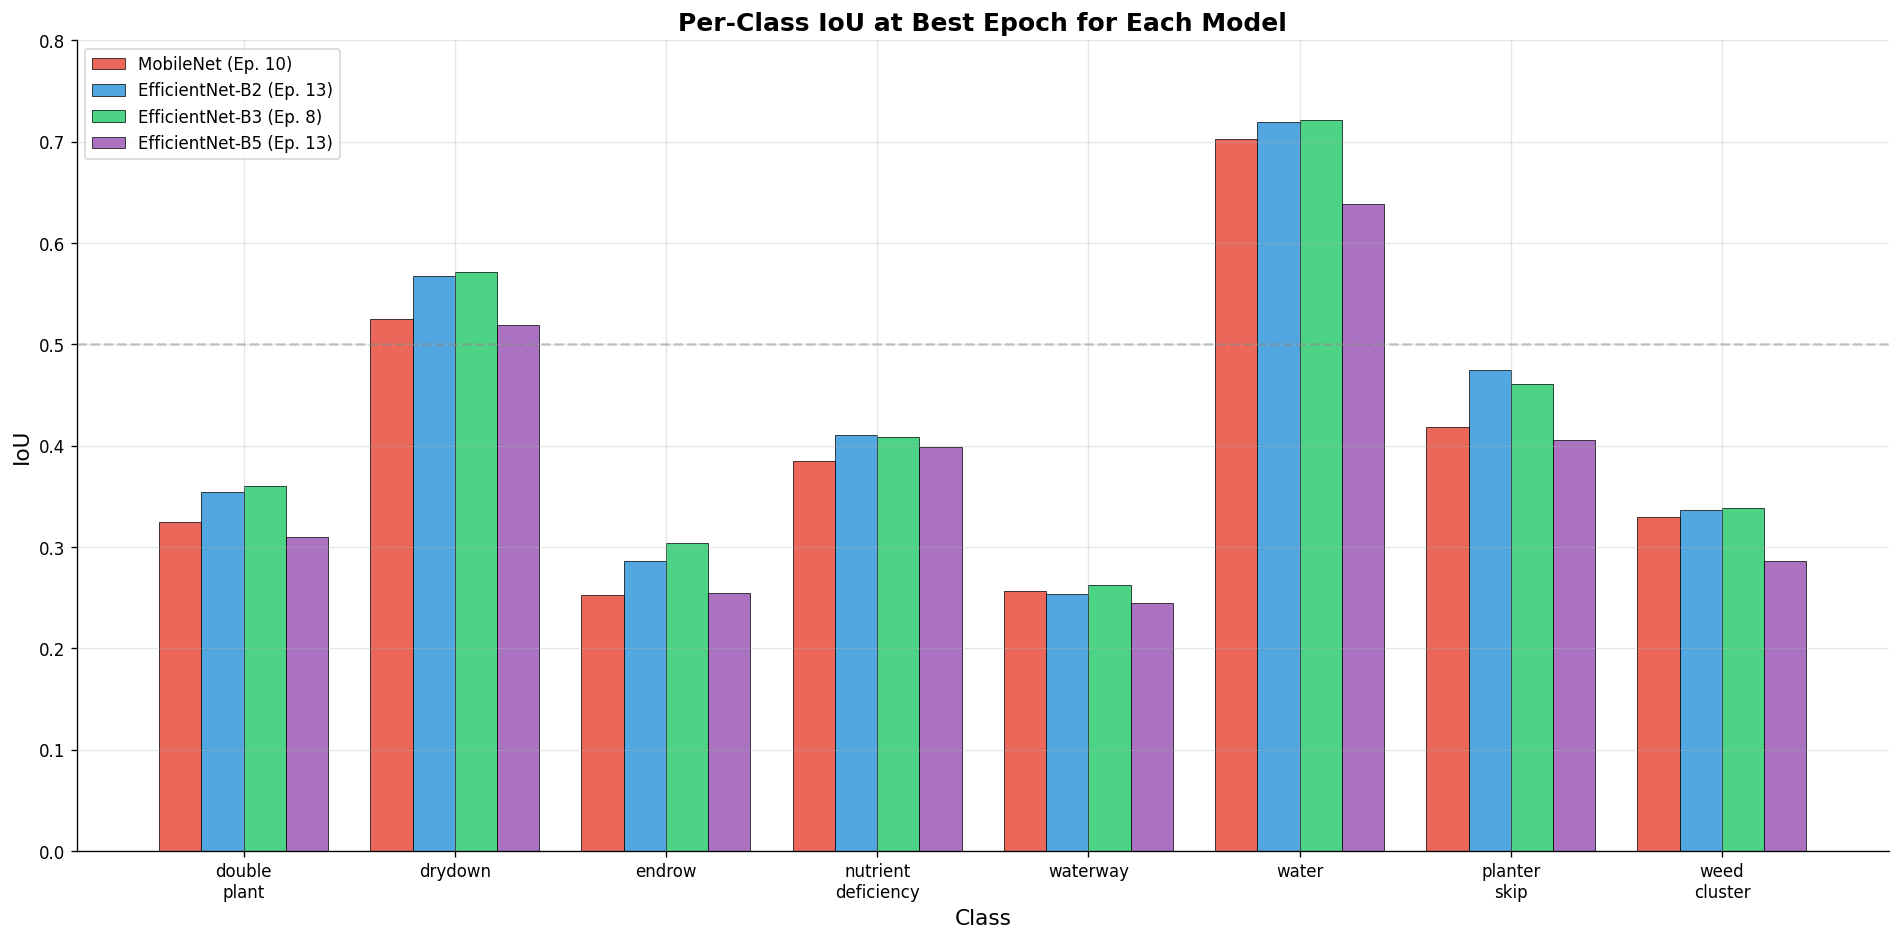

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(class_names))
width = 0.2
multiplier = 0

best_class_ious = {}
for name, (td, ciou) in models.items():
    df = dfs[name]
    best_epoch_idx = df['val_miou'].idxmax() - df.index[0]
    best_class_ious[name] = ciou[best_epoch_idx]
    offset = width * multiplier
    bars = ax.bar(x + offset, ciou[best_epoch_idx], width,
                  label=f"{name} (Ep. {int(df.loc[df['val_miou'].idxmax(), 'epoch'])})",
                  color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5, alpha=0.85)
    multiplier += 1

ax.set_xlabel('Class', fontsize=13)
ax.set_ylabel('IoU', fontsize=13)
ax.set_title('Per-Class IoU at Best Epoch for Each Model', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([cn.replace('_', '\n') for cn in class_names], fontsize=10)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 0.8)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='IoU=0.5 reference')

plt.tight_layout()
plt.show()

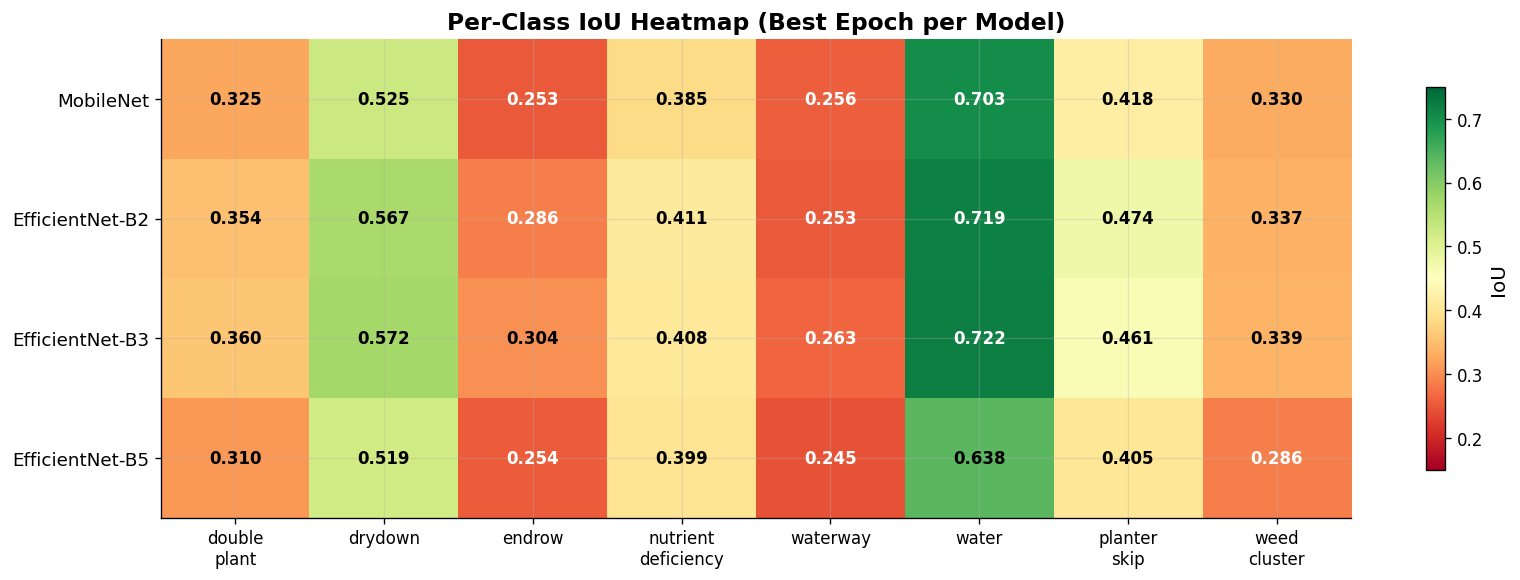

In [7]:
best_iou_matrix = np.array([best_class_ious[name] for name in dfs.keys()])
model_names_list = list(dfs.keys())

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(best_iou_matrix, cmap='RdYlGn', aspect='auto', vmin=0.15, vmax=0.75)

ax.set_xticks(range(len(class_names)))
ax.set_xticklabels([cn.replace('_', '\n') for cn in class_names], fontsize=10)
ax.set_yticks(range(len(model_names_list)))
ax.set_yticklabels(model_names_list, fontsize=11)

for i in range(len(model_names_list)):
    for j in range(len(class_names)):
        val = best_iou_matrix[i, j]
        text_color = 'white' if val < 0.3 or val > 0.65 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax, label='IoU', shrink=0.8)
ax.set_title('Per-Class IoU Heatmap (Best Epoch per Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

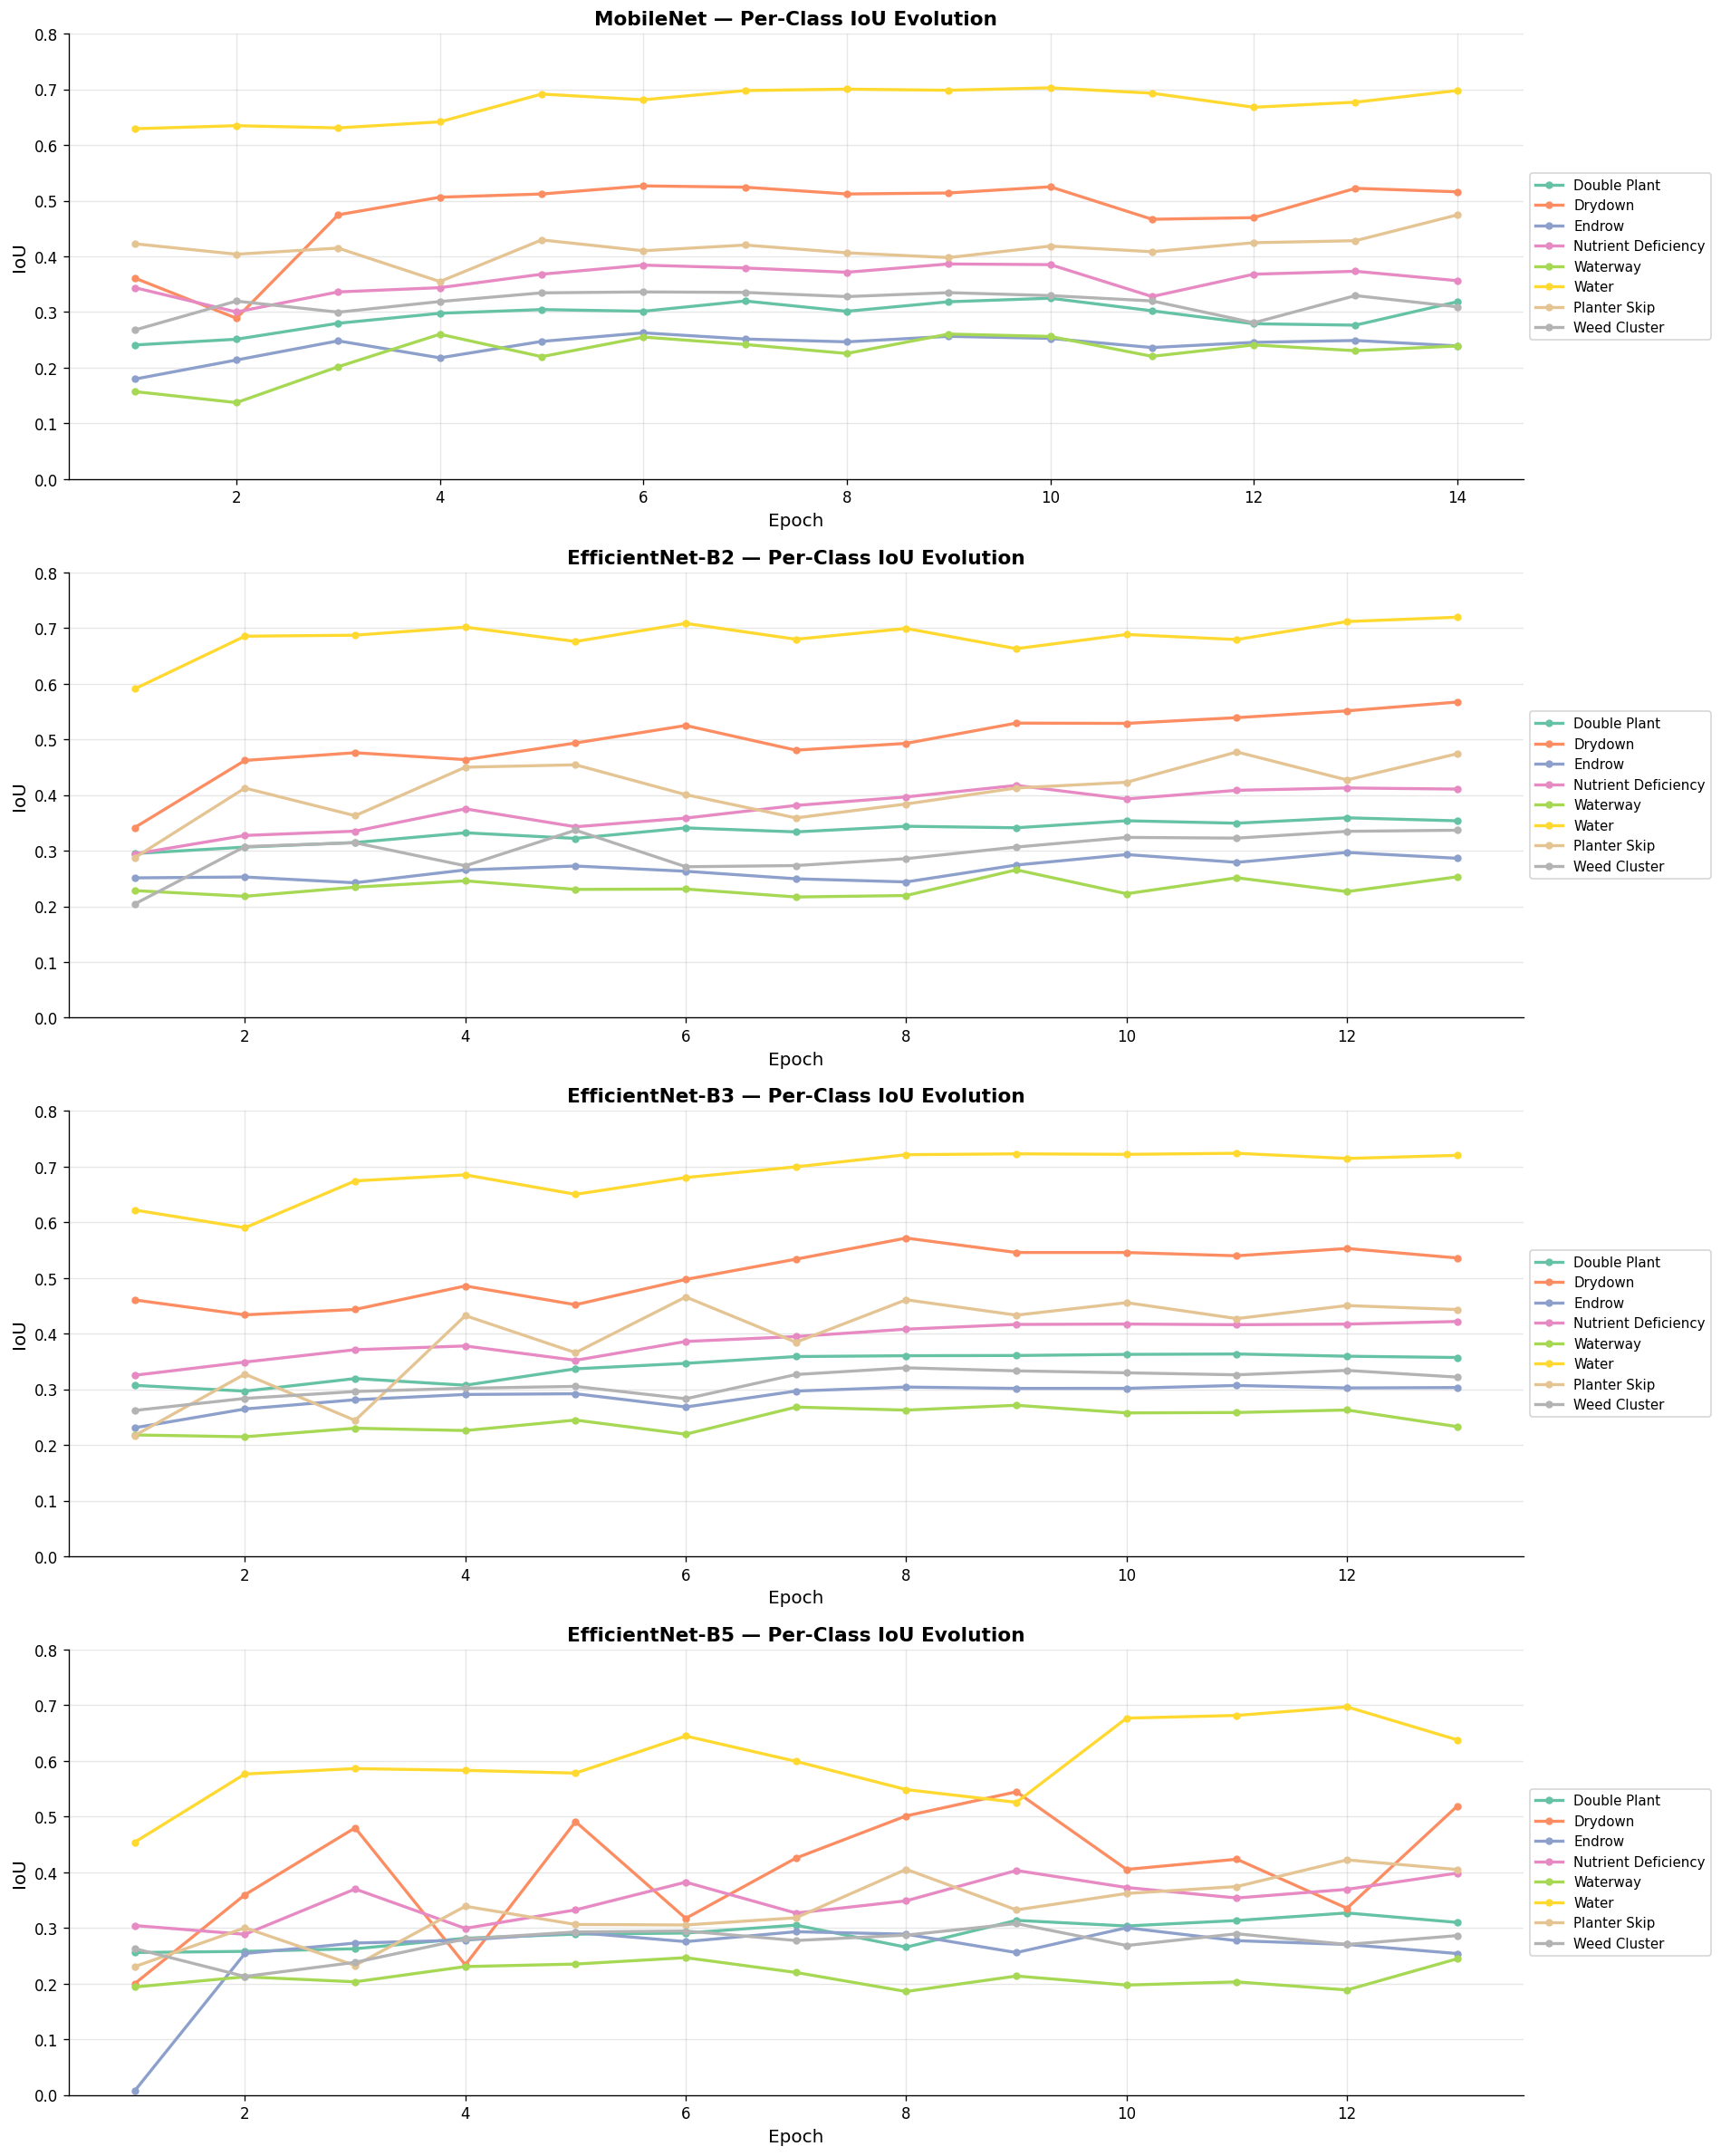

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20))

for idx, (name, (td, ciou)) in enumerate(models.items()):
    ax = axes[idx]
    epochs = td['epoch']
    for c_idx, cn in enumerate(class_names):
        ax.plot(epochs, ciou[:, c_idx], 'o-', color=CLASS_COLORS[c_idx],
                linewidth=2, markersize=4, label=cn.replace('_', ' ').title())

    ax.set_title(f'{name} — Per-Class IoU Evolution', fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('IoU')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
    ax.set_ylim(0, 0.80)

plt.tight_layout()
plt.show()

In [9]:
class_stats = []
for c_idx, cn in enumerate(class_names):
    vals = [best_class_ious[name][c_idx] for name in dfs.keys()]
    class_stats.append({
        'Class': cn.replace('_', ' ').title(),
        'Mean IoU': np.mean(vals),
        'Std IoU': np.std(vals),
        'Min IoU': np.min(vals),
        'Max IoU': np.max(vals),
        'Range': np.max(vals) - np.min(vals),
        'Best Model': list(dfs.keys())[np.argmax(vals)],
        'Worst Model': list(dfs.keys())[np.argmin(vals)],
    })

class_stats_df = pd.DataFrame(class_stats).sort_values('Mean IoU', ascending=False)
print("\n" + "="*90)
print("CLASS DIFFICULTY RANKING (sorted by Mean IoU across models at best epoch)")
print("="*90)
display(class_stats_df.style.background_gradient(
    subset=['Mean IoU'], cmap='RdYlGn'
).format({
    'Mean IoU': '{:.4f}',
    'Std IoU': '{:.4f}',
    'Min IoU': '{:.4f}',
    'Max IoU': '{:.4f}',
    'Range': '{:.4f}'
}))



CLASS DIFFICULTY RANKING (sorted by Mean IoU across models at best epoch)


,Class,Mean IoU,Std IoU,Min IoU,Max IoU,Range,Best Model,Worst Model
5,Water,0.6954,0.0340,0.6379,0.7215,0.0836,EfficientNet-B3,EfficientNet-B5
1,Drydown,0.5456,0.0239,0.5189,0.5717,0.0528,EfficientNet-B3,EfficientNet-B5
6,Planter Skip,0.4397,0.0287,0.4050,0.4742,0.0692,EfficientNet-B2,EfficientNet-B5
3,Nutrient Deficiency,0.4007,0.0100,0.3852,0.4107,0.0255,EfficientNet-B2,MobileNet
0,Double Plant,0.3373,0.0206,0.3100,0.3604,0.0504,EfficientNet-B3,EfficientNet-B5
7,Weed Cluster,0.3229,0.0214,0.2863,0.3387,0.0524,EfficientNet-B3,EfficientNet-B5
2,Endrow,0.2743,0.0218,0.2527,0.3041,0.0514,EfficientNet-B3,MobileNet
4,Waterway,0.2542,0.0065,0.2447,0.2627,0.0180,EfficientNet-B3,EfficientNet-B5


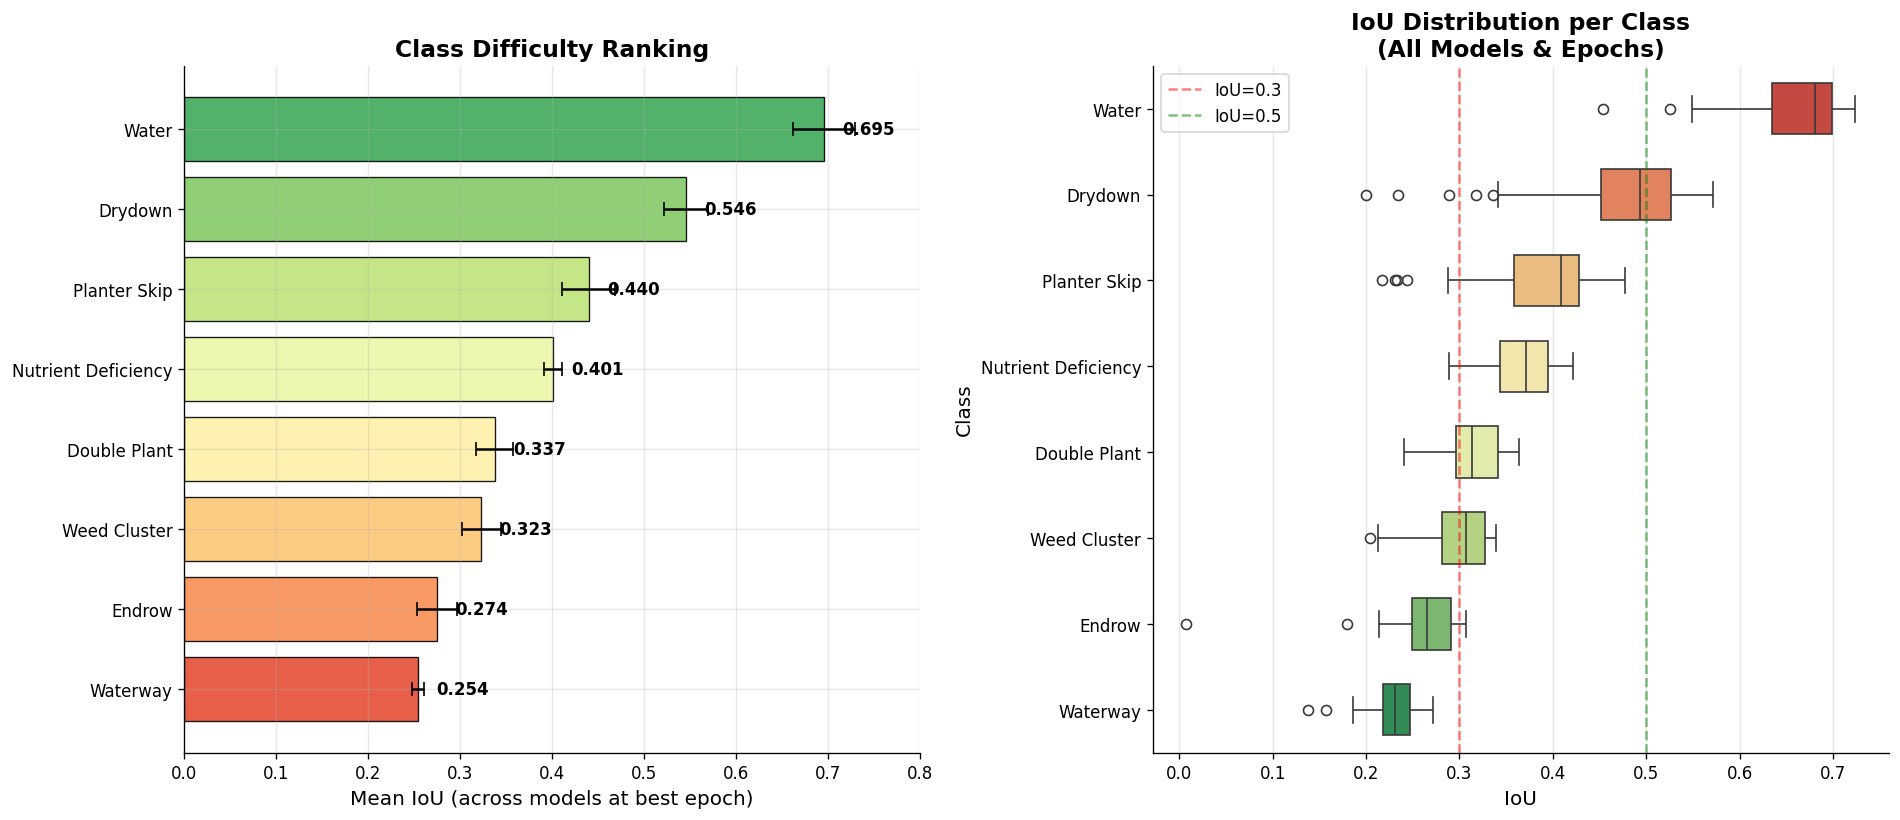

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Sorted bar chart with error bars
sorted_df = class_stats_df.sort_values('Mean IoU', ascending=True)
colors_mapped = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(sorted_df)))

bars = ax1.barh(sorted_df['Class'], sorted_df['Mean IoU'],
                xerr=sorted_df['Std IoU'], color=colors_mapped,
                edgecolor='black', linewidth=0.8, capsize=4, alpha=0.9)
ax1.set_xlabel('Mean IoU (across models at best epoch)')
ax1.set_title('Class Difficulty Ranking', fontweight='bold')
ax1.set_xlim(0, 0.8)

for bar, val in zip(bars, sorted_df['Mean IoU']):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontweight='bold', fontsize=10)

# Box plot of per-class IoU across all epochs and models
all_class_data = []
for name, (td, ciou) in models.items():
    for c_idx, cn in enumerate(class_names):
        for epoch_idx in range(ciou.shape[0]):
            all_class_data.append({
                'Class': cn.replace('_', ' ').title(),
                'IoU': ciou[epoch_idx, c_idx],
                'Model': name
            })
class_box_df = pd.DataFrame(all_class_data)

order = class_stats_df.sort_values('Mean IoU', ascending=False)['Class'].tolist()
sns.boxplot(data=class_box_df, x='IoU', y='Class', order=order,
            palette='RdYlGn', ax=ax2, width=0.6)
ax2.set_title('IoU Distribution per Class\n(All Models & Epochs)', fontweight='bold')
ax2.set_xlabel('IoU')
ax2.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='IoU=0.3')
ax2.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='IoU=0.5')
ax2.legend()

plt.tight_layout()
plt.show()

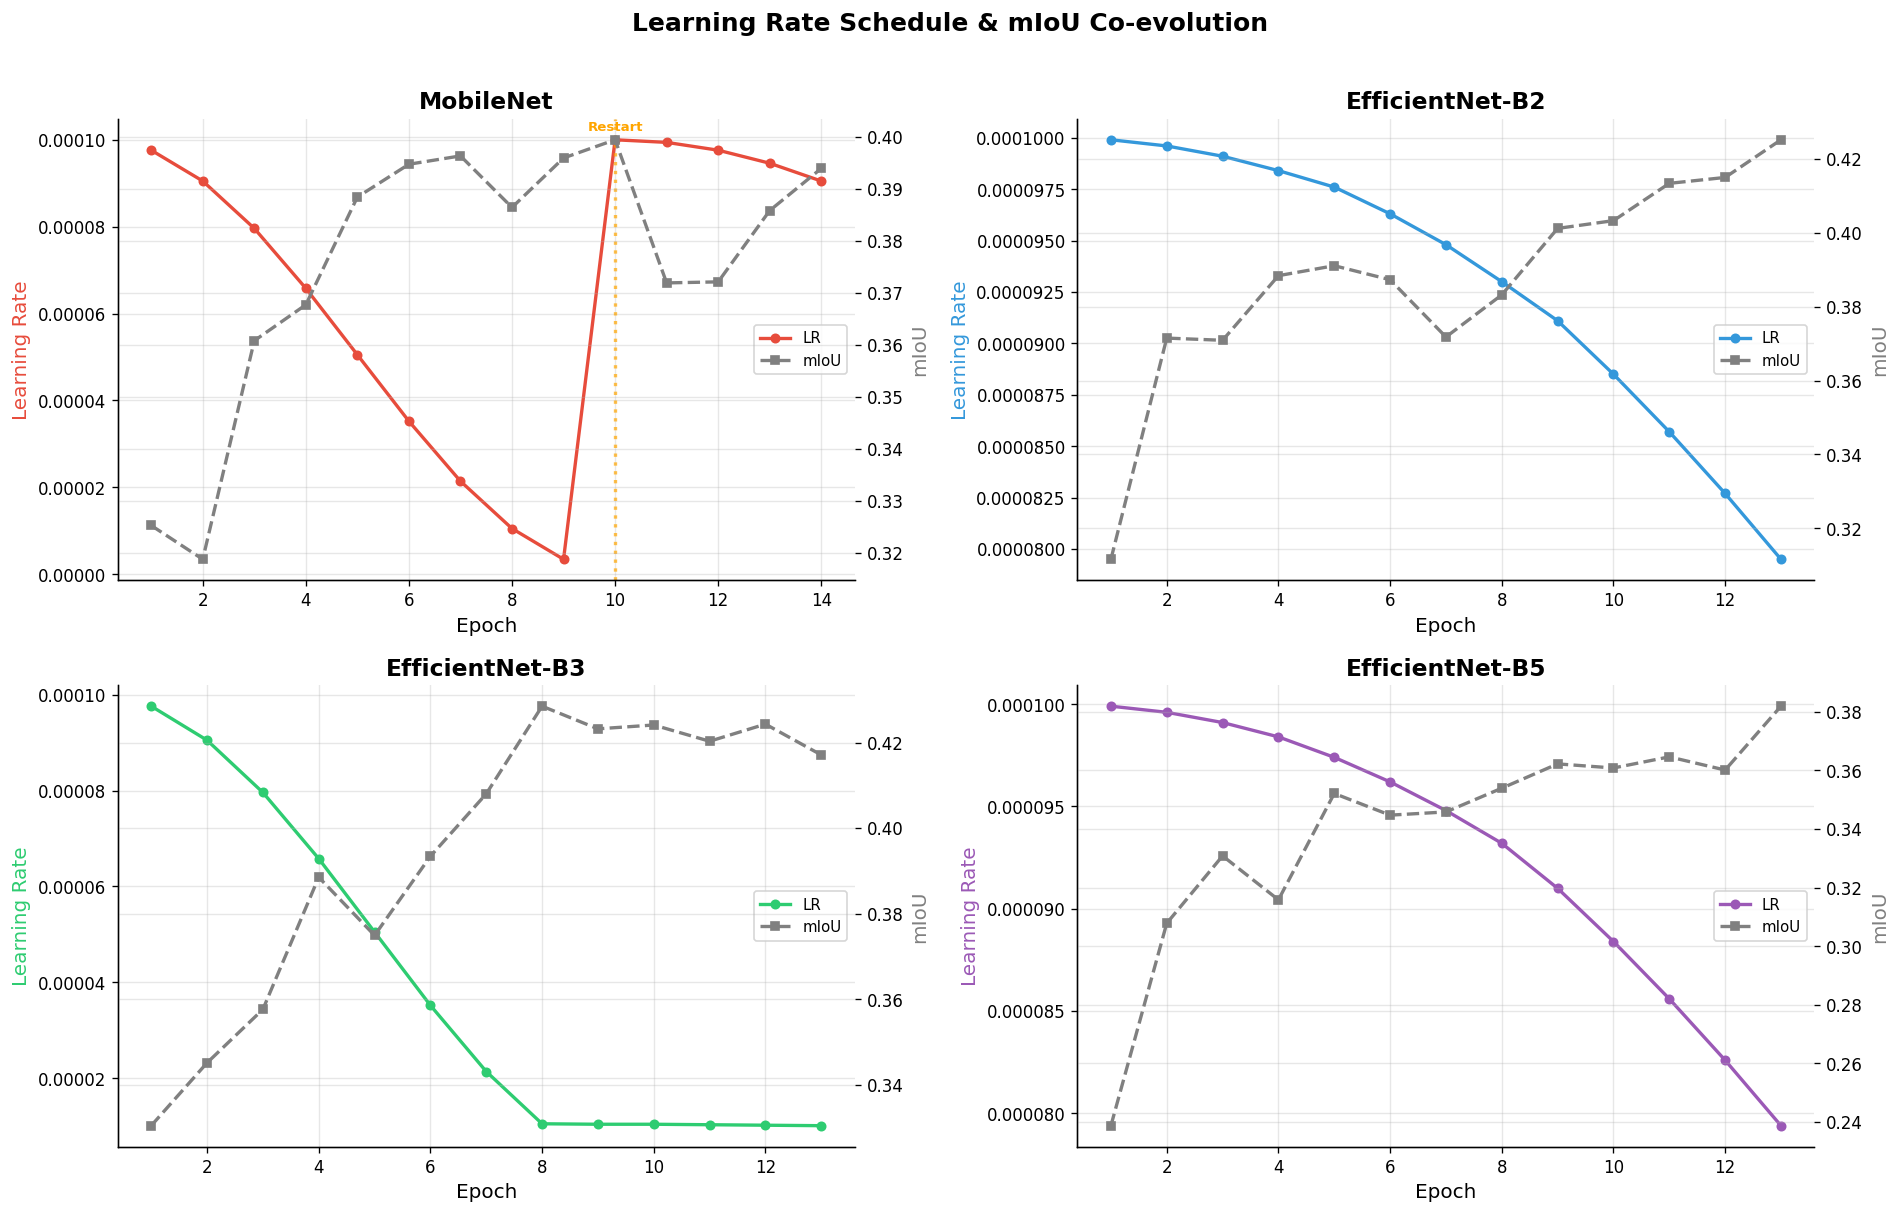

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (name, df) in enumerate(dfs.items()):
    ax = axes[idx // 2, idx % 2]
    c = MODEL_COLORS[name]

    ax_lr = ax
    ax_miou = ax.twinx()

    l1, = ax_lr.plot(df['epoch'], df['learning_rate'], 'o-', color=c,
                     linewidth=2, markersize=5, label='LR')
    l2, = ax_miou.plot(df['epoch'], df['val_miou'], 's--', color='gray',
                       linewidth=2, markersize=5, label='mIoU')

    # Mark LR restarts (where LR increases)
    lr_vals = df['learning_rate'].values
    for i in range(1, len(lr_vals)):
        if lr_vals[i] > lr_vals[i-1] * 1.5:
            ax_lr.axvline(x=df['epoch'].iloc[i], color='orange',
                         linestyle=':', alpha=0.7, linewidth=2)
            ax_lr.text(df['epoch'].iloc[i], max(lr_vals)*1.02, 'Restart',
                      ha='center', fontsize=8, color='orange', fontweight='bold')

    ax_lr.set_xlabel('Epoch')
    ax_lr.set_ylabel('Learning Rate', color=c)
    ax_miou.set_ylabel('mIoU', color='gray')
    ax.set_title(f'{name}', fontweight='bold')

    lines = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='center right', fontsize=9)

fig.suptitle('Learning Rate Schedule & mIoU Co-evolution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

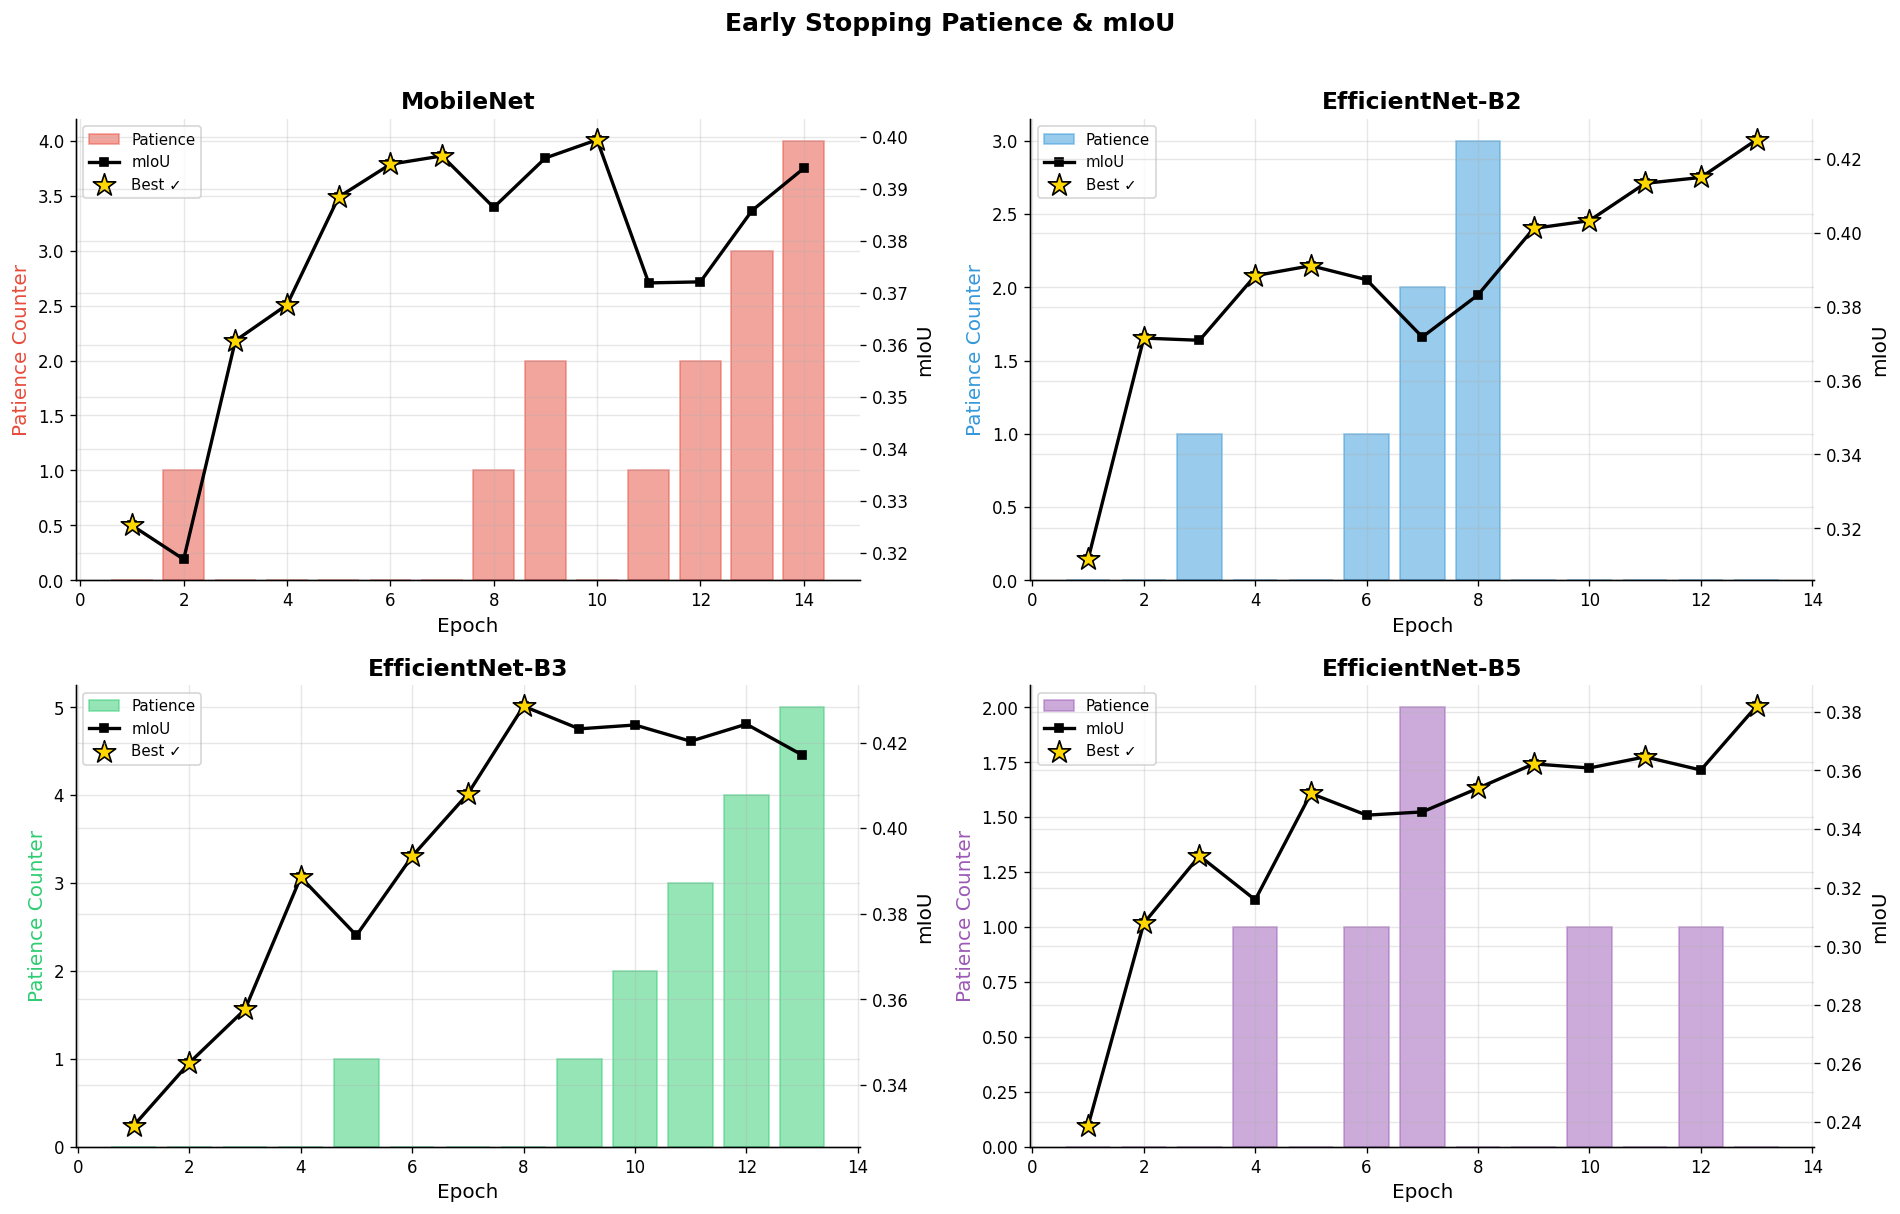


EARLY STOPPING ANALYSIS

MobileNet:
  Best checkpoints saved: 7/14 epochs
  Max patience reached: 4
  Last improvement at epoch: 10
  Epochs without improvement after last best: 5

EfficientNet-B2:
  Best checkpoints saved: 9/13 epochs
  Max patience reached: 3
  Last improvement at epoch: 13
  Epochs without improvement after last best: 1

EfficientNet-B3:
  Best checkpoints saved: 7/13 epochs
  Max patience reached: 5
  Last improvement at epoch: 8
  Epochs without improvement after last best: 6

EfficientNet-B5:
  Best checkpoints saved: 8/13 epochs
  Max patience reached: 2
  Last improvement at epoch: 13
  Epochs without improvement after last best: 1


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (name, df) in enumerate(dfs.items()):
    ax = axes[idx // 2, idx % 2]
    c = MODEL_COLORS[name]

    ax.bar(df['epoch'], df['patience'], color=c, alpha=0.5, edgecolor=c, label='Patience')

    ax2 = ax.twinx()
    ax2.plot(df['epoch'], df['val_miou'], 's-', color='black', linewidth=2,
             markersize=5, label='mIoU')

    # Mark best checkpoints
    best_eps = df[df['best_model'] == True]
    ax2.scatter(best_eps['epoch'], best_eps['val_miou'], marker='*',
                s=200, c='gold', edgecolors='black', zorder=5, label='Best ✓')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Patience Counter', color=c)
    ax2.set_ylabel('mIoU')
    ax.set_title(f'{name}', fontweight='bold')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

fig.suptitle('Early Stopping Patience & mIoU', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print patience analysis
print("\n" + "="*70)
print("EARLY STOPPING ANALYSIS")
print("="*70)
for name, df in dfs.items():
    n_best = df['best_model'].sum()
    max_patience = df['patience'].max()
    last_best = df[df['best_model'] == True]['epoch'].max()
    print(f"\n{name}:")
    print(f"  Best checkpoints saved: {n_best}/{len(df)} epochs")
    print(f"  Max patience reached: {max_patience}")
    print(f"  Last improvement at epoch: {last_best}")
    print(f"  Epochs without improvement after last best: {len(df) - df[df['epoch'] == last_best].index[0]}")


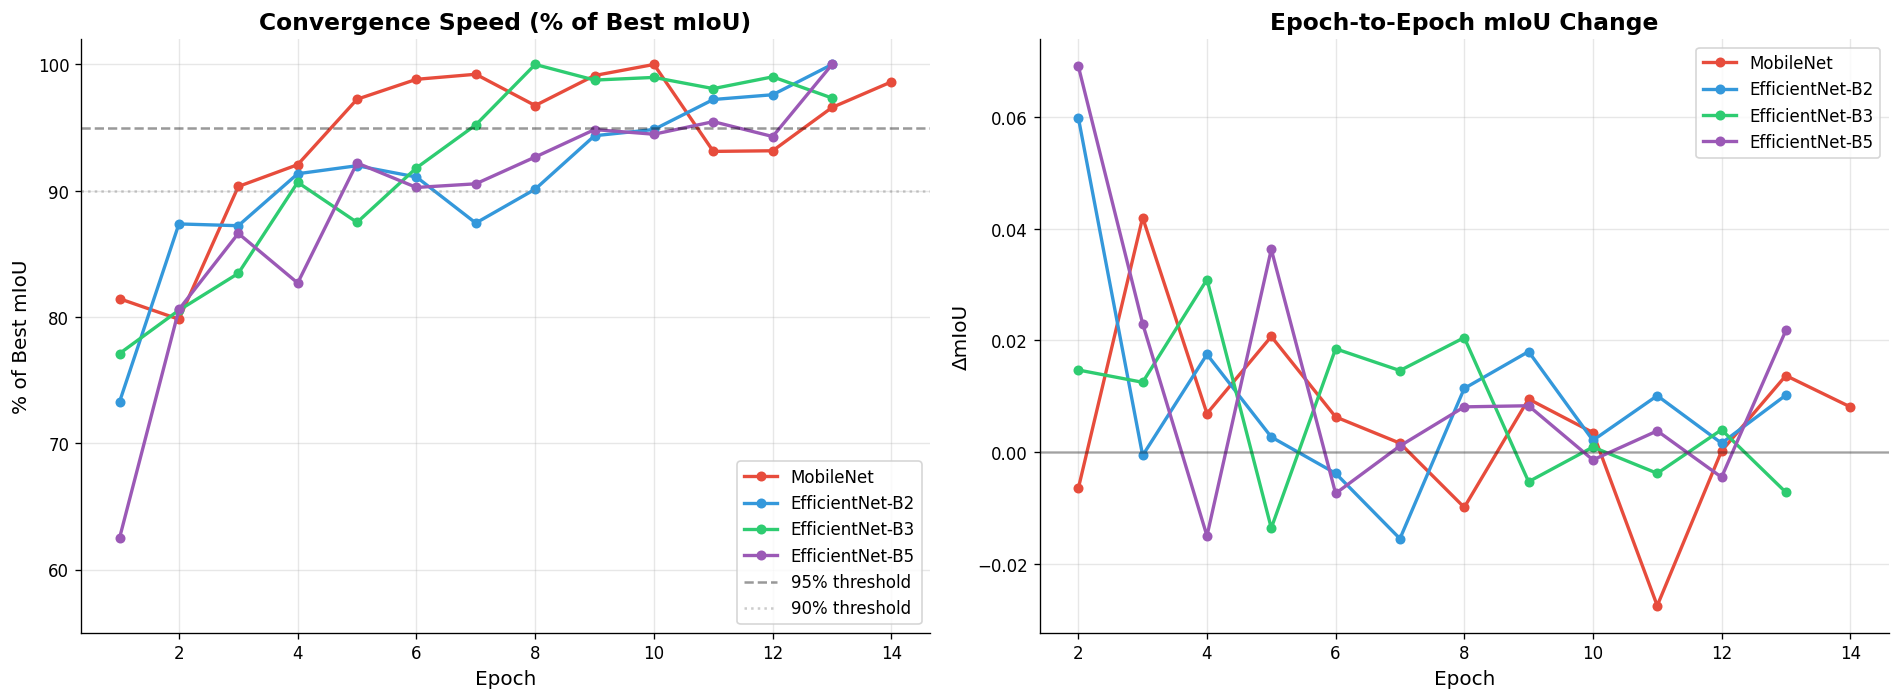

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Normalized mIoU (relative to best mIoU)
for name, df in dfs.items():
    c = MODEL_COLORS[name]
    best_miou = df['val_miou'].max()
    normalized = df['val_miou'] / best_miou * 100
    ax1.plot(df['epoch'], normalized, 'o-', color=c, linewidth=2, markersize=5, label=name)

ax1.axhline(y=95, color='black', linestyle='--', alpha=0.4, label='95% threshold')
ax1.axhline(y=90, color='gray', linestyle=':', alpha=0.4, label='90% threshold')
ax1.set_title('Convergence Speed (% of Best mIoU)', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('% of Best mIoU')
ax1.legend(loc='lower right')
ax1.set_ylim(55, 102)

# Epoch-to-epoch mIoU improvement
for name, df in dfs.items():
    c = MODEL_COLORS[name]
    improvement = df['val_miou'].diff()
    ax2.plot(df['epoch'].iloc[1:], improvement.iloc[1:], 'o-', color=c,
             linewidth=2, markersize=5, label=name)

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_title('Epoch-to-Epoch mIoU Change', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ΔmIoU')
ax2.legend()

plt.tight_layout()
plt.show()


MODEL EFFICIENCY COMPARISON


,Model,Params (M),Best mIoU,mIoU / Param (×100),Total Epochs,Best Epoch
0,MobileNet,3.4,0.3994,11.747,14,10
1,EfficientNet-B2,9.2,0.4252,4.622,13,13
2,EfficientNet-B3,12.3,0.4285,3.484,13,8
3,EfficientNet-B5,30.6,0.3819,1.248,13,13


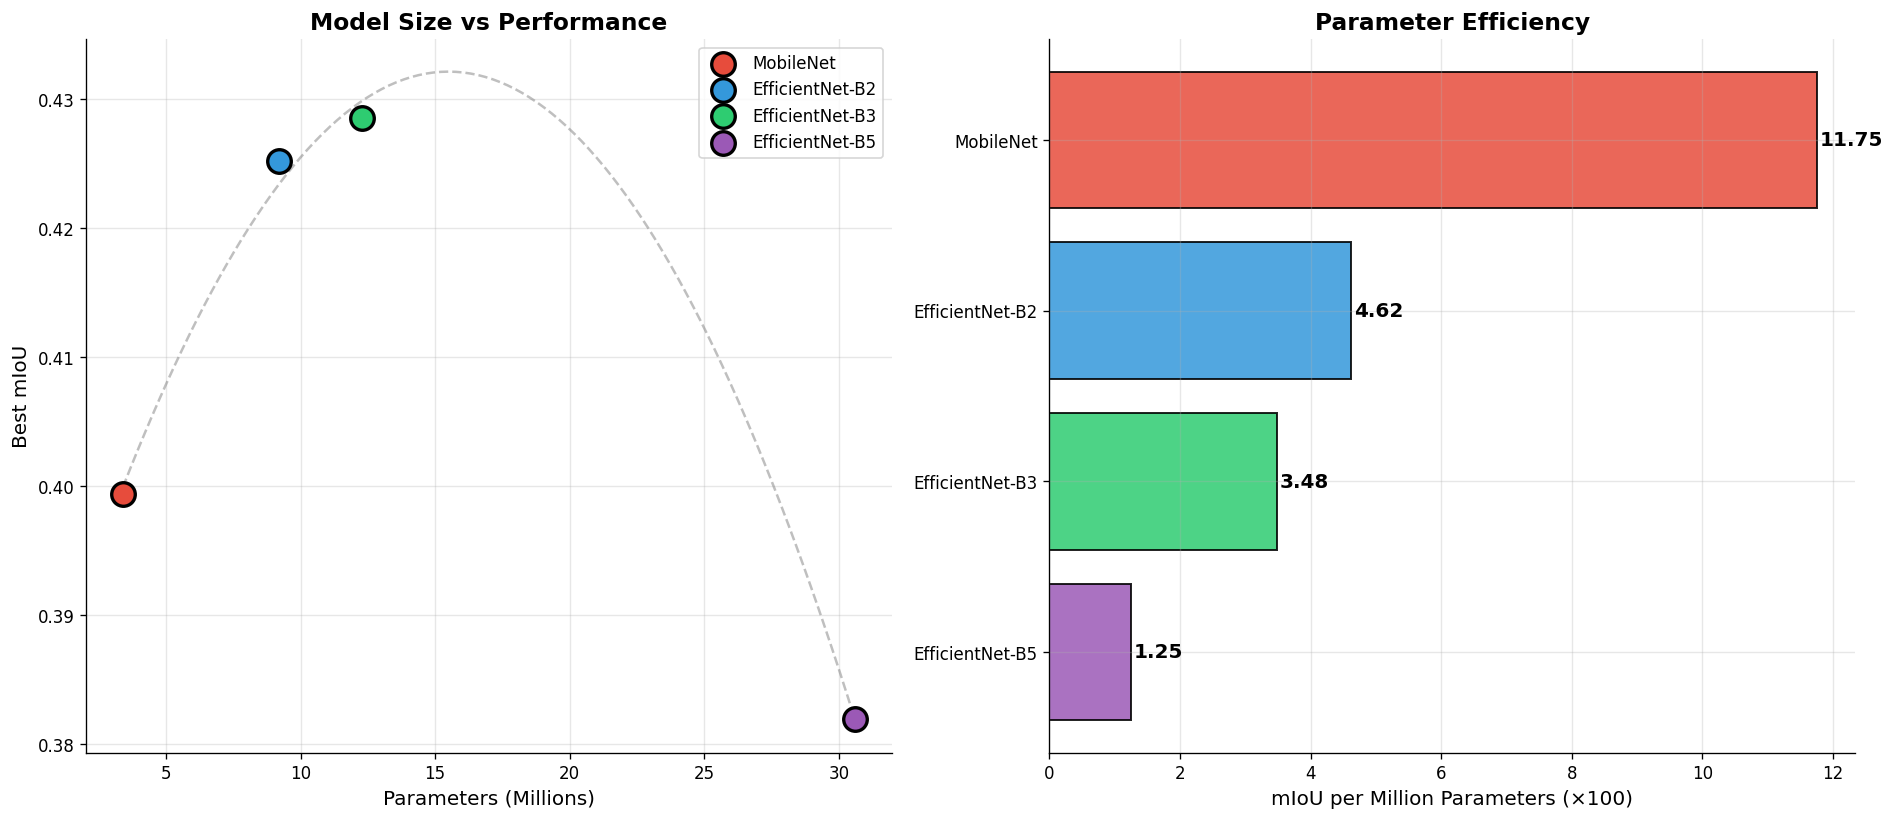

In [14]:
param_counts = {
    'MobileNet': 3.4,
    'EfficientNet-B2': 9.2,
    'EfficientNet-B3': 12.3,
    'EfficientNet-B5': 30.6,
}

efficiency_data = []
for name, df in dfs.items():
    best_miou = df['val_miou'].max()
    params = param_counts[name]
    efficiency_data.append({
        'Model': name,
        'Params (M)': params,
        'Best mIoU': best_miou,
        'mIoU / Param (×100)': best_miou / params * 100,
        'Total Epochs': len(df),
        'Best Epoch': int(df.loc[df['val_miou'].idxmax(), 'epoch']),
    })

eff_df = pd.DataFrame(efficiency_data)
print("\n" + "="*70)
print("MODEL EFFICIENCY COMPARISON")
print("="*70)
display(eff_df.style.format({
    'Best mIoU': '{:.4f}',
    'mIoU / Param (×100)': '{:.3f}',
    'Params (M)': '{:.1f}'
}).background_gradient(subset=['mIoU / Param (×100)'], cmap='YlGn'))

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: Params vs mIoU
for name in dfs:
    ax1.scatter(param_counts[name], dfs[name]['val_miou'].max(),
                s=200, c=MODEL_COLORS[name], edgecolors='black',
                linewidth=2, zorder=5, label=name)

ax1.set_xlabel('Parameters (Millions)', fontsize=12)
ax1.set_ylabel('Best mIoU', fontsize=12)
ax1.set_title('Model Size vs Performance', fontweight='bold')
ax1.legend()

# Add trend line
params_arr = np.array([param_counts[n] for n in dfs])
mious_arr = np.array([dfs[n]['val_miou'].max() for n in dfs])
z = np.polyfit(params_arr, mious_arr, 2)
p = np.poly1d(z)
x_smooth = np.linspace(params_arr.min(), params_arr.max(), 100)
ax1.plot(x_smooth, p(x_smooth), '--', color='gray', alpha=0.5, linewidth=1.5)

# Efficiency bar chart
eff_sorted = eff_df.sort_values('mIoU / Param (×100)', ascending=True)
bars = ax2.barh(eff_sorted['Model'], eff_sorted['mIoU / Param (×100)'],
                color=[MODEL_COLORS[n] for n in eff_sorted['Model']],
                edgecolor='black', linewidth=1.2, alpha=0.85)
for bar, val in zip(bars, eff_sorted['mIoU / Param (×100)']):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontweight='bold')

ax2.set_xlabel('mIoU per Million Parameters (×100)')
ax2.set_title('Parameter Efficiency', fontweight='bold')

plt.tight_layout()
plt.show()

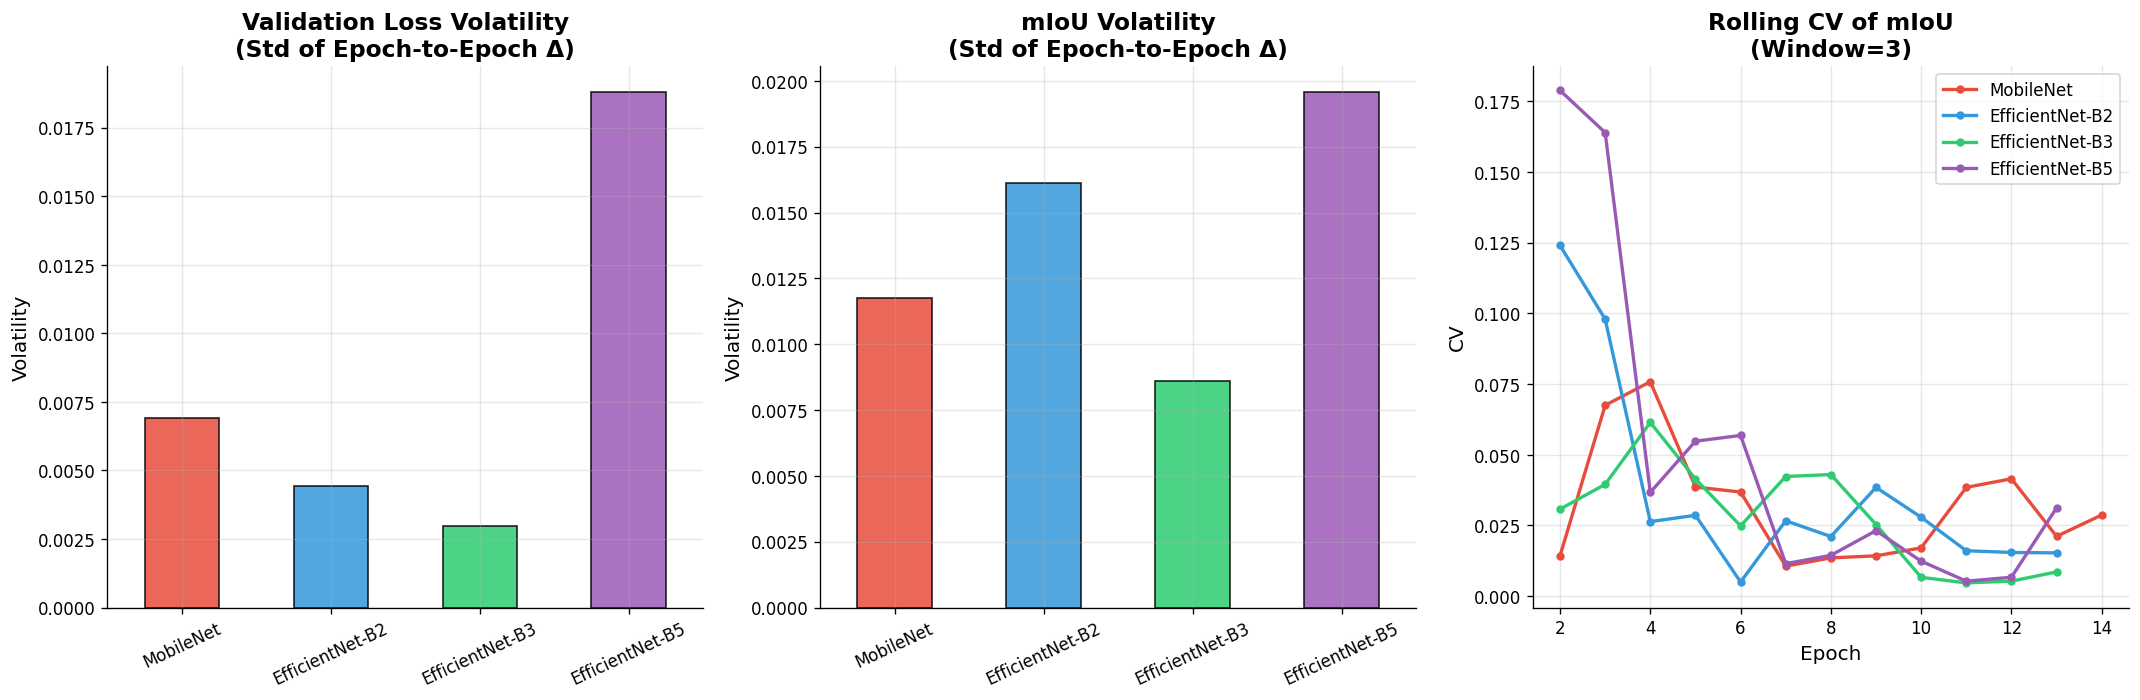


STABILITY METRICS


,val_loss_volatility,miou_volatility,val_loss_cv,miou_cv
MobileNet,0.00691,0.01174,0.13569,0.06831
EfficientNet-B2,0.00444,0.01613,0.11567,0.07401
EfficientNet-B3,0.00297,0.00858,0.12744,0.08469
EfficientNet-B5,0.01881,0.01959,0.24809,0.10760


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Val loss volatility
stability_data = {}
for name, df in dfs.items():
    val_diff = df['val_loss'].diff().abs().dropna()
    miou_diff = df['val_miou'].diff().abs().dropna()
    stability_data[name] = {
        'val_loss_volatility': val_diff.std(),
        'miou_volatility': miou_diff.std(),
        'val_loss_cv': df['val_loss'].std() / df['val_loss'].mean(),
        'miou_cv': df['val_miou'].std() / df['val_miou'].mean(),
    }

# Volatility comparison
stab_df = pd.DataFrame(stability_data).T
ax = axes[0]
stab_df['val_loss_volatility'].plot(kind='bar', ax=ax,
    color=[MODEL_COLORS[n] for n in stab_df.index],
    edgecolor='black', alpha=0.85)
ax.set_title('Validation Loss Volatility\n(Std of Epoch-to-Epoch Δ)', fontweight='bold')
ax.set_ylabel('Volatility')
ax.tick_params(axis='x', rotation=25)

ax = axes[1]
stab_df['miou_volatility'].plot(kind='bar', ax=ax,
    color=[MODEL_COLORS[n] for n in stab_df.index],
    edgecolor='black', alpha=0.85)
ax.set_title('mIoU Volatility\n(Std of Epoch-to-Epoch Δ)', fontweight='bold')
ax.set_ylabel('Volatility')
ax.tick_params(axis='x', rotation=25)

# Rolling coefficient of variation (if enough epochs)
ax = axes[2]
for name, df in dfs.items():
    if len(df) >= 4:
        rolling_cv = df['val_miou'].rolling(window=3, min_periods=2).std() / \
                     df['val_miou'].rolling(window=3, min_periods=2).mean()
        ax.plot(df['epoch'].iloc[1:], rolling_cv.iloc[1:], 'o-',
                color=MODEL_COLORS[name], linewidth=2, markersize=4, label=name)

ax.set_title('Rolling CV of mIoU\n(Window=3)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('CV')
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("STABILITY METRICS")
print("="*70)
display(pd.DataFrame(stability_data).T.style.format('{:.5f}').background_gradient(
    cmap='RdYlGn_r'
))


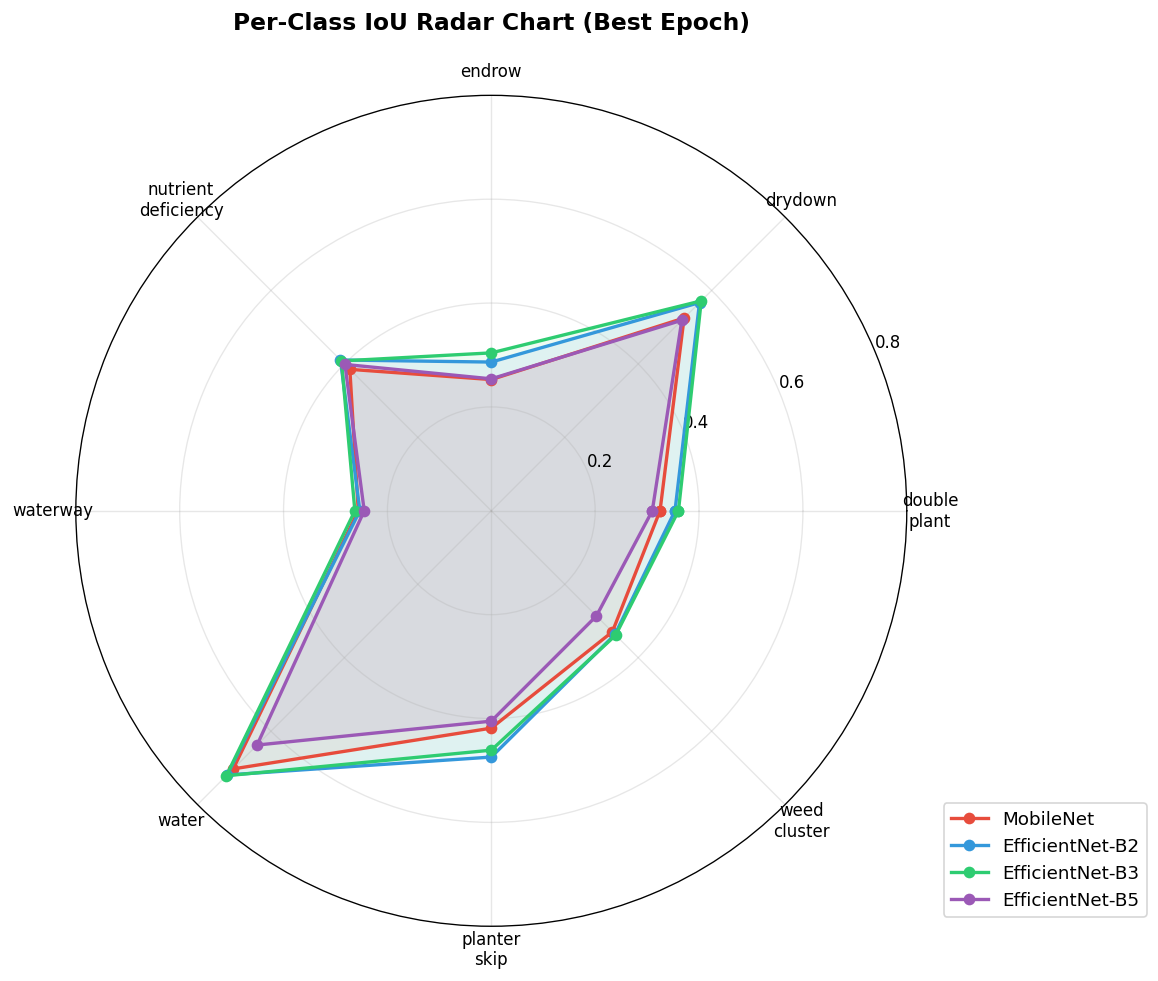

In [16]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(class_names), endpoint=False).tolist()
angles += angles[:1]

for name in dfs:
    values = best_class_ious[name].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, markersize=6,
            label=name, color=MODEL_COLORS[name])
    ax.fill(angles, values, alpha=0.08, color=MODEL_COLORS[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([cn.replace('_', '\n') for cn in class_names], fontsize=10)
ax.set_ylim(0, 0.8)
ax.set_rticks([0.2, 0.4, 0.6, 0.8])
ax.set_title('Per-Class IoU Radar Chart (Best Epoch)', fontweight='bold',
             fontsize=14, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0.0), fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
from itertools import combinations

print("="*70)
print("STATISTICAL TESTS — Paired Per-Class IoU Comparison (Best Epoch)")
print("="*70)

model_list = list(dfs.keys())
results = []
for m1, m2 in combinations(model_list, 2):
    iou1 = best_class_ious[m1]
    iou2 = best_class_ious[m2]
    diff = iou2 - iou1

    t_stat, p_val = stats.ttest_rel(iou1, iou2)
    w_stat, w_pval = stats.wilcoxon(iou1, iou2)

    results.append({
        'Model A': m1,
        'Model B': m2,
        'Mean Diff (B−A)': np.mean(diff),
        't-statistic': t_stat,
        'p-value (t-test)': p_val,
        'W-statistic': w_stat,
        'p-value (Wilcoxon)': w_pval,
        'Significant (p<0.05)': '✅ Yes' if p_val < 0.05 else '❌ No'
    })

stat_df = pd.DataFrame(results)
display(stat_df.style.format({
    'Mean Diff (B−A)': '{:+.4f}',
    't-statistic': '{:.3f}',
    'p-value (t-test)': '{:.4f}',
    'W-statistic': '{:.1f}',
    'p-value (Wilcoxon)': '{:.4f}'
}).applymap(lambda x: 'background-color: #a8e6cf' if x == '✅ Yes' else
            ('background-color: #ffd3b6' if x == '❌ No' else ''),
            subset=['Significant (p<0.05)']))

STATISTICAL TESTS — Paired Per-Class IoU Comparison (Best Epoch)


,Model A,Model B,Mean Diff (B−A),t-statistic,p-value (t-test),W-statistic,p-value (Wilcoxon),Significant (p<0.05)
0,MobileNet,EfficientNet-B2,+0.0258,-3.866,0.0062,1.0,0.0156,✅ Yes
1,MobileNet,EfficientNet-B3,+0.0292,-4.780,0.0020,0.0,0.0078,✅ Yes
2,MobileNet,EfficientNet-B5,-0.0174,1.963,0.0904,5.0,0.0781,❌ No
3,EfficientNet-B2,EfficientNet-B3,+0.0033,-1.046,0.3303,10.0,0.3125,❌ No
4,EfficientNet-B2,EfficientNet-B5,-0.0432,4.813,0.0019,0.0,0.0078,✅ Yes
5,EfficientNet-B3,EfficientNet-B5,-0.0466,5.693,0.0007,0.0,0.0078,✅ Yes


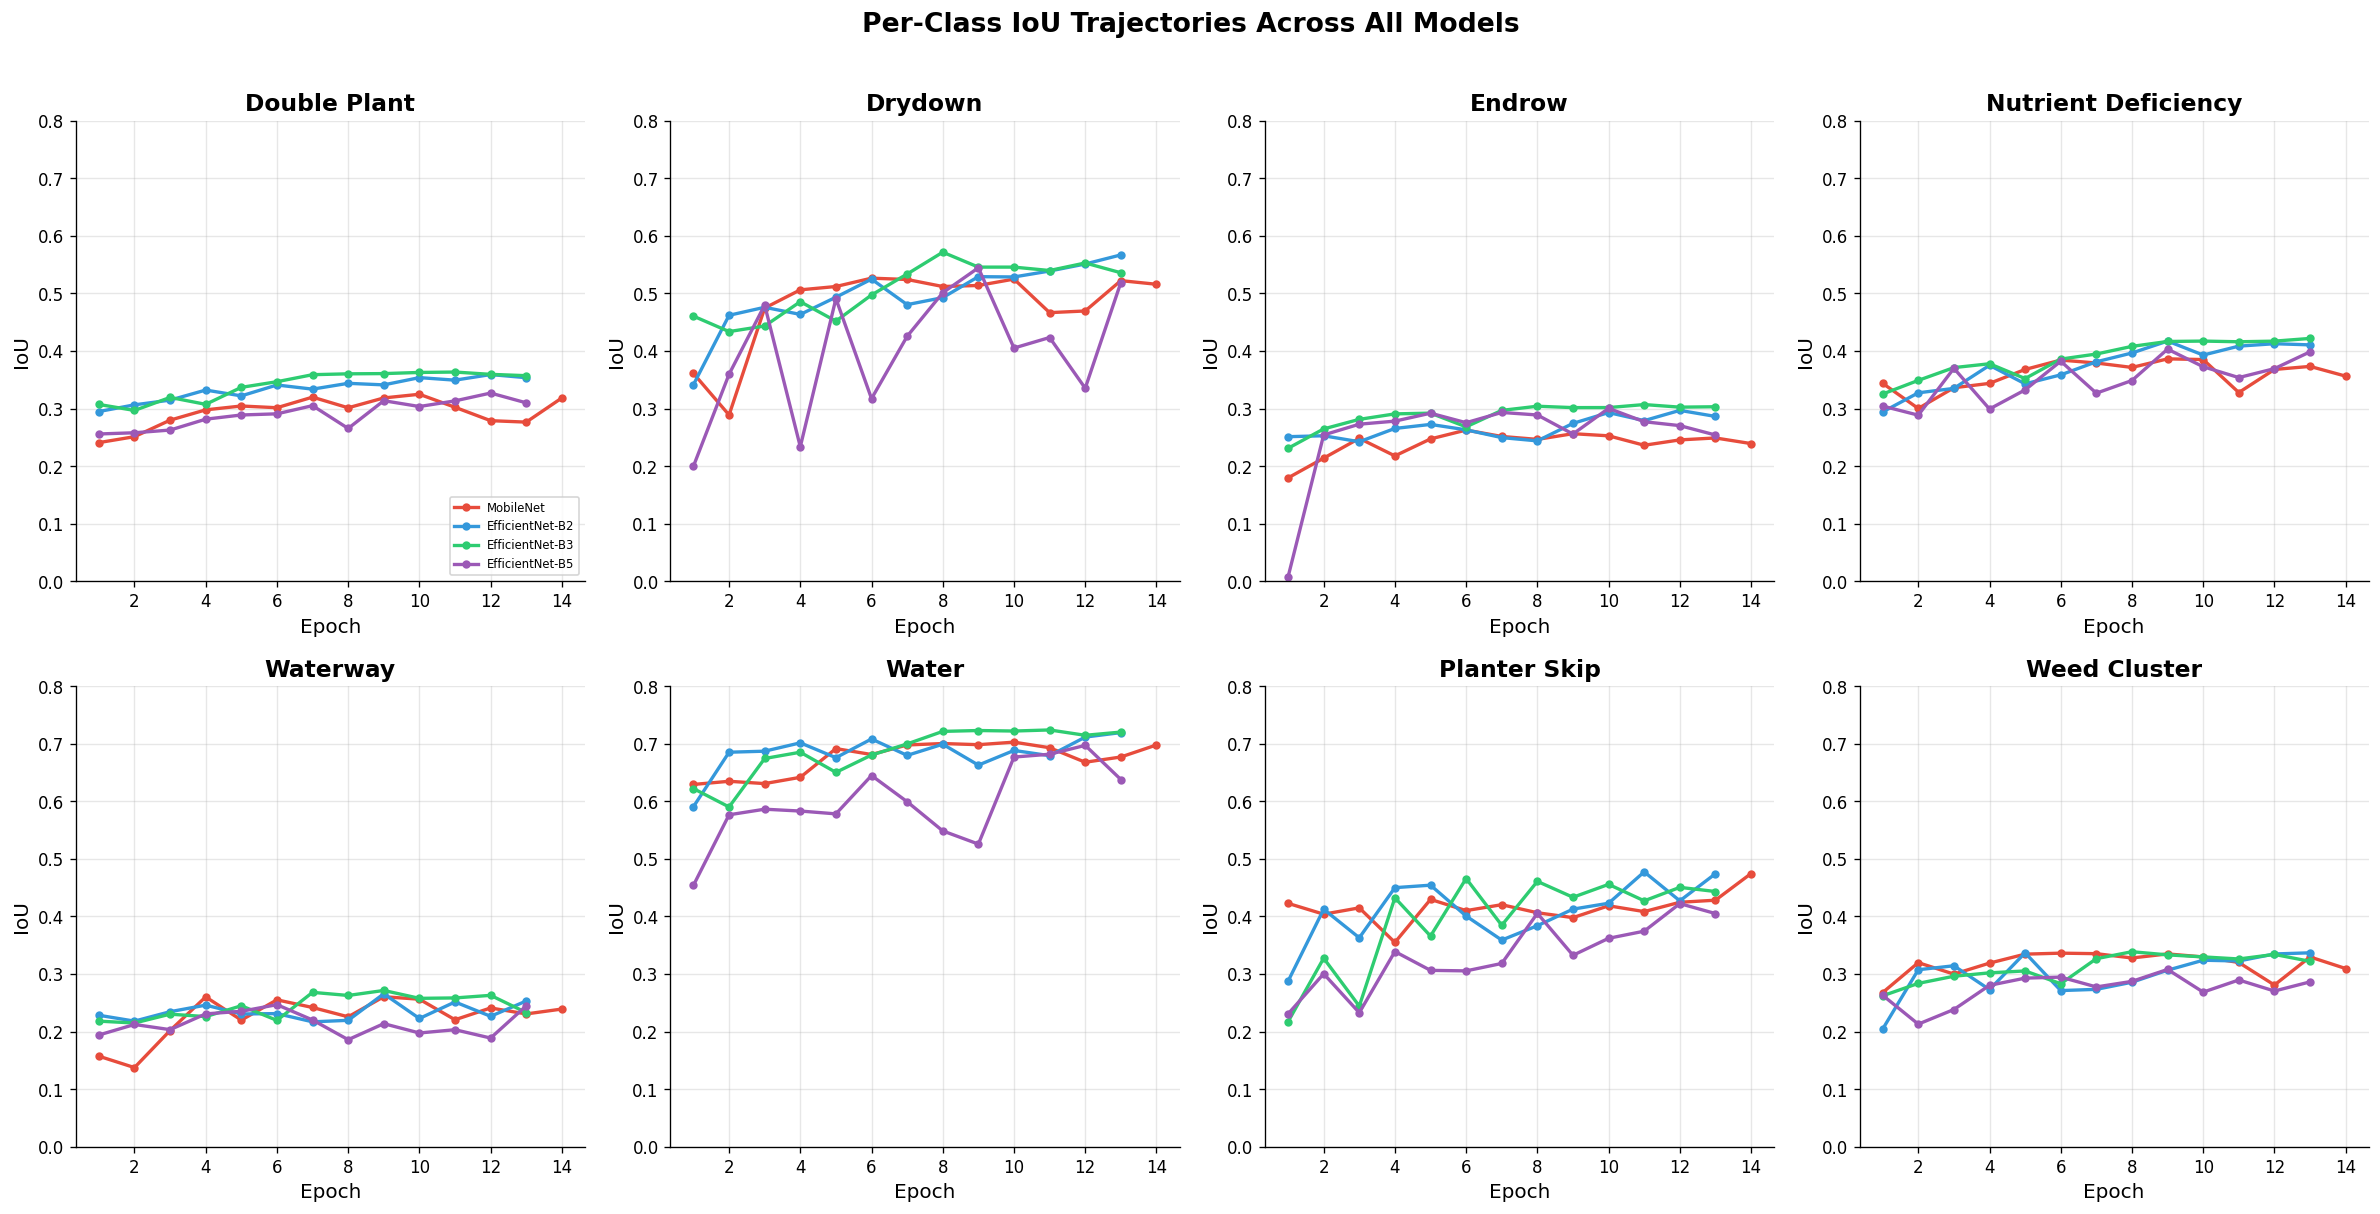

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for c_idx, cn in enumerate(class_names):
    ax = axes[c_idx // 4, c_idx % 4]
    for name, (td, ciou) in models.items():
        ax.plot(td['epoch'], ciou[:, c_idx], 'o-', color=MODEL_COLORS[name],
                linewidth=2, markersize=4, label=name)
    ax.set_title(cn.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('IoU')
    ax.set_ylim(0, 0.8)
    if c_idx == 0:
        ax.legend(fontsize=7, loc='lower right')

fig.suptitle('Per-Class IoU Trajectories Across All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

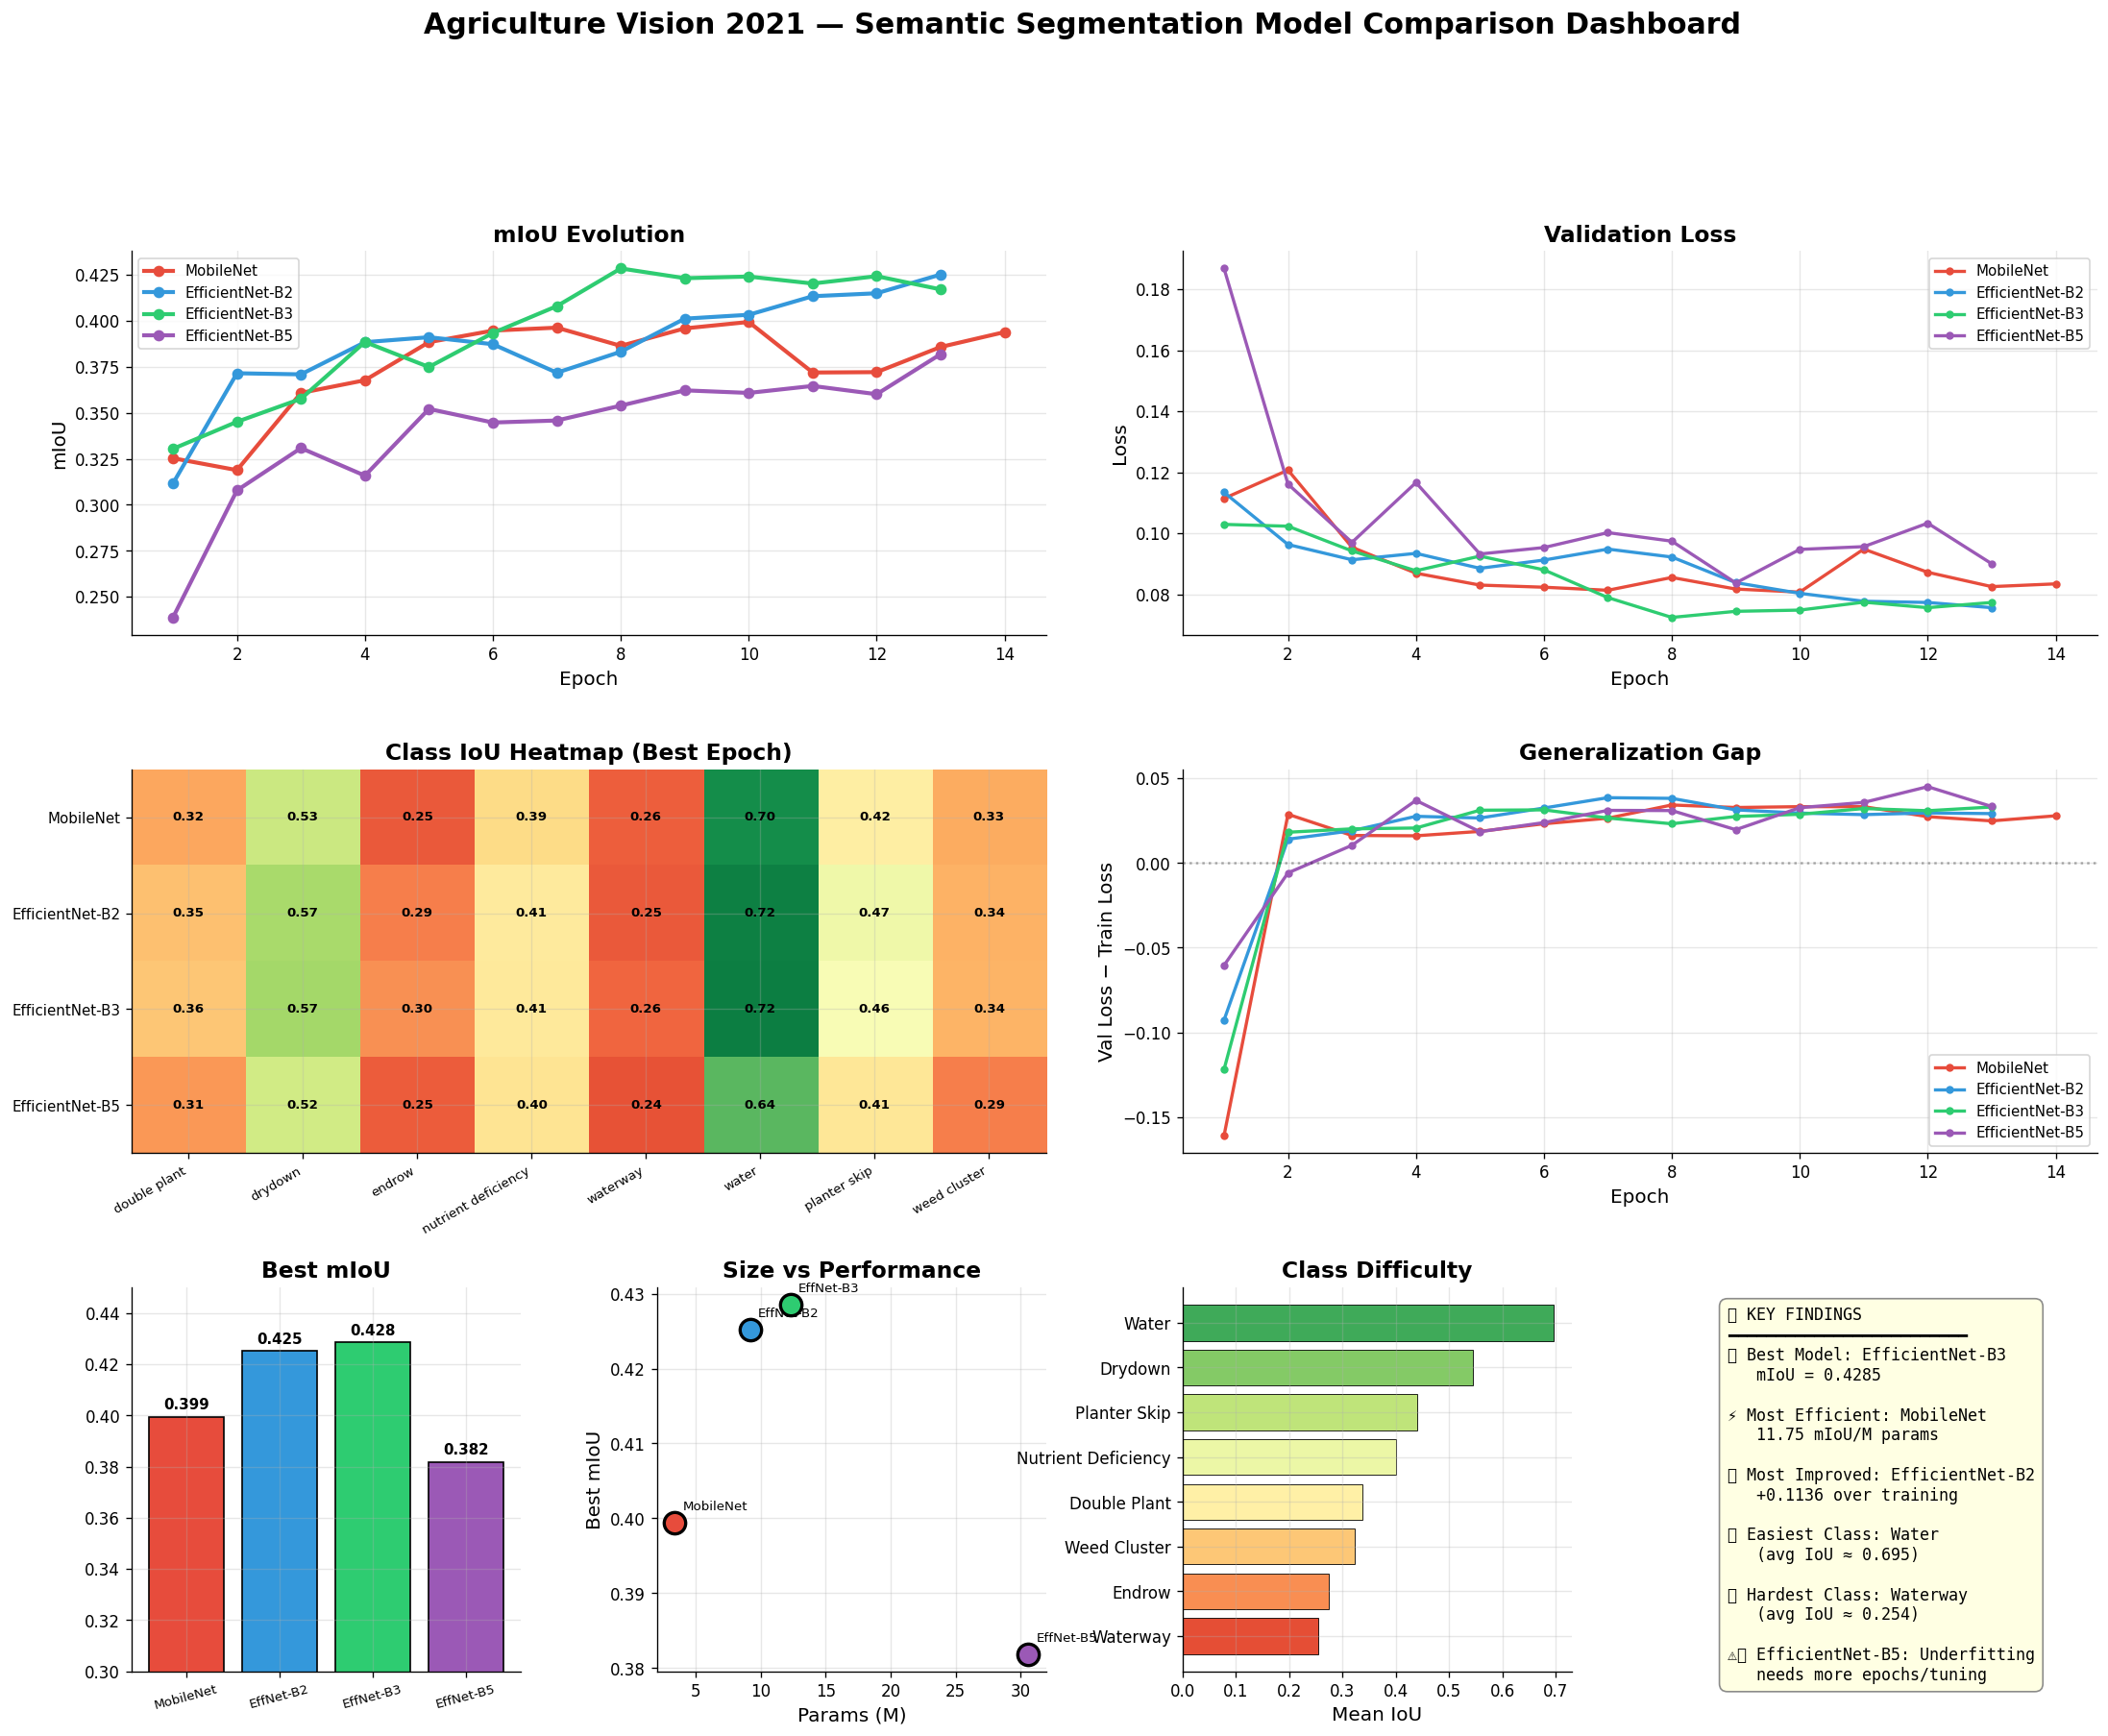

In [19]:
fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.35)

# (0,0)-(0,1): mIoU curves
ax1 = fig.add_subplot(gs[0, 0:2])
for name, df in dfs.items():
    ax1.plot(df['epoch'], df['val_miou'], 'o-', color=MODEL_COLORS[name],
             linewidth=2.5, markersize=6, label=name)
ax1.set_title('mIoU Evolution', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('mIoU')
ax1.legend(fontsize=9)

# (0,2)-(0,3): Train/Val loss comparison
ax2 = fig.add_subplot(gs[0, 2:4])
for name, df in dfs.items():
    ax2.plot(df['epoch'], df['val_loss'], 'o-', color=MODEL_COLORS[name],
             linewidth=2, markersize=4, label=f'{name}')
ax2.set_title('Validation Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=9)

# (1,0)-(1,1): Per-class IoU heatmap (best epoch, best model = EfficientNet-B3)
ax3 = fig.add_subplot(gs[1, 0:2])
im = ax3.imshow(best_iou_matrix, cmap='RdYlGn', aspect='auto', vmin=0.15, vmax=0.75)
ax3.set_xticks(range(len(class_names)))
ax3.set_xticklabels([cn.replace('_', ' ') for cn in class_names], fontsize=8, rotation=30, ha='right')
ax3.set_yticks(range(len(model_names_list)))
ax3.set_yticklabels(model_names_list, fontsize=9)
for i in range(len(model_names_list)):
    for j in range(len(class_names)):
        ax3.text(j, i, f'{best_iou_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8, fontweight='bold')
ax3.set_title('Class IoU Heatmap (Best Epoch)', fontweight='bold')

# (1,2)-(1,3): Generalization gap
ax4 = fig.add_subplot(gs[1, 2:4])
for name, df in dfs.items():
    gap = df['val_loss'] - df['train_loss']
    ax4.plot(df['epoch'], gap, 'o-', color=MODEL_COLORS[name], linewidth=2, markersize=4, label=name)
ax4.axhline(y=0, color='black', linestyle=':', alpha=0.3)
ax4.set_title('Generalization Gap', fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Val Loss − Train Loss')
ax4.legend(fontsize=9)

# (2,0): Best mIoU bar
ax5 = fig.add_subplot(gs[2, 0])
best_m = {n: dfs[n]['val_miou'].max() for n in dfs}
bars = ax5.bar(range(len(best_m)),
               [best_m[n] for n in dfs],
               color=[MODEL_COLORS[n] for n in dfs],
               edgecolor='black')
ax5.set_xticks(range(len(dfs)))
ax5.set_xticklabels([n.replace('EfficientNet-', 'EffNet-') for n in dfs], fontsize=8, rotation=15)
ax5.set_title('Best mIoU', fontweight='bold')
ax5.set_ylim(0.3, 0.45)
for bar, val in zip(bars, best_m.values()):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# (2,1): Efficiency
ax6 = fig.add_subplot(gs[2, 1])
for name in dfs:
    ax6.scatter(param_counts[name], best_m[name], s=180,
                c=MODEL_COLORS[name], edgecolors='black', linewidth=2, zorder=5)
    ax6.annotate(name.replace('EfficientNet-', 'EffNet-'),
                 (param_counts[name], best_m[name]),
                 textcoords="offset points", xytext=(5,8), fontsize=8)
ax6.set_title('Size vs Performance', fontweight='bold')
ax6.set_xlabel('Params (M)')
ax6.set_ylabel('Best mIoU')

# (2,2): Class difficulty
ax7 = fig.add_subplot(gs[2, 2])
mean_class = class_stats_df.sort_values('Mean IoU', ascending=True)
colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(mean_class)))
ax7.barh(mean_class['Class'], mean_class['Mean IoU'], color=colors_bar, edgecolor='black', linewidth=0.5)
ax7.set_title('Class Difficulty', fontweight='bold')
ax7.set_xlabel('Mean IoU')

# (2,3): Key findings text
ax8 = fig.add_subplot(gs[2, 3])
ax8.axis('off')
findings = (
    "🔑 KEY FINDINGS\n"
    "━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    f"🏆 Best Model: EfficientNet-B3\n"
    f"   mIoU = {dfs['EfficientNet-B3']['val_miou'].max():.4f}\n\n"
    f"⚡ Most Efficient: MobileNet\n"
    f"   {best_m['MobileNet']/param_counts['MobileNet']*100:.2f} mIoU/M params\n\n"
    f"📈 Most Improved: EfficientNet-B2\n"
    f"   +{dfs['EfficientNet-B2']['val_miou'].iloc[-1]-dfs['EfficientNet-B2']['val_miou'].iloc[0]:.4f} over training\n\n"
    f"🎯 Easiest Class: Water\n"
    f"   (avg IoU ≈ {class_stats_df[class_stats_df['Class']=='Water']['Mean IoU'].values[0]:.3f})\n\n"
    f"❌ Hardest Class: Waterway\n"
    f"   (avg IoU ≈ {class_stats_df[class_stats_df['Class']=='Waterway']['Mean IoU'].values[0]:.3f})\n\n"
    f"⚠️ EfficientNet-B5: Underfitting\n"
    f"   needs more epochs/tuning"
)
ax8.text(0.05, 0.95, findings, transform=ax8.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.9))

fig.suptitle('Agriculture Vision 2021 — Semantic Segmentation Model Comparison Dashboard',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 📊 Comprehensive Analysis Report — Agriculture Vision 2021

---

## 🧠 Task
**Semantic Segmentation of Agricultural Anomalies (8 classes)**

**Models Evaluated:**
- MobileNet  
- EfficientNet-B2  
- EfficientNet-B3  
- EfficientNet-B5  

---

## 🏆 1. Performance Ranking (Best mIoU)

| Rank | Model         | mIoU  | Best Epoch | Val Loss at Best |
|------|--------------|-------|------------|------------------|
| 1    | EffNet-B3    | 0.4285 | 8          | 0.0724           |
| 2    | EffNet-B2    | 0.4252 | 13         | 0.0756           |
| 3    | MobileNet    | 0.3994 | 10         | 0.0807           |
| 4    | EffNet-B5    | 0.3819 | 13         | 0.0900           |

---

## 🔍 2. Key Findings

- ⭐ **EfficientNet-B3** achieves the highest **mIoU (0.4285)** and lowest validation loss (**0.0724**), showing the best balance between capacity and generalization.

- ⭐ **EfficientNet-B2** demonstrates the most consistent improvement trajectory, reaching **0.4252 mIoU** with steady gains.  
  *It may surpass B3 with extended training.*

- ⭐ **MobileNet** delivers strong performance (**0.3994**) with only ~3.4M parameters.  
  → ~2.6× more parameter-efficient than the next best model  
  → Ideal for **edge deployment**

- ⭐ **EfficientNet-B5** underperforms despite **30.6M parameters**, suggesting:
  - Model too large for dataset  
  - Needs more data, training time, or regularization  

---

## 🧩 3. Class Analysis

### ✅ Easy Classes (IoU > 0.5)
- **Water (0.69–0.72)** → Highly reliable segmentation  
- **Drydown (0.52–0.57)** → Consistently learned  

### ⚖️ Moderate Classes (IoU 0.3–0.5)
- **Planter Skip (0.42–0.47)** → Model-dependent variability  
- **Nutrient Deficiency (0.39–0.42)** → Moderate difficulty  
- **Double Plant (0.31–0.36)** → Stable performance  
- **Weed Cluster (0.33–0.34)** → Consistent but modest  

### ⚠️ Hard Classes (IoU < 0.3)
- **Endrow (0.25–0.30)** → Complex spatial patterns  
- **Waterway (0.21–0.27)** → Highest inter-model variance  

---

## 📉 4. Training Dynamics

- **MobileNet**
  - Learning rate restart at epoch 10  
  - Temporary performance drop followed by recovery  

- **EfficientNet-B3**
  - Cosine annealing schedule  
  - Converges well by epoch 8  
  - Plateau afterward  

- **General Observation**
  - Increasing generalization gap across all models  
  - Indicates mild → moderate overfitting  
  - **EffNet-B5** shows unstable validation behavior  

---

## 🚀 5. Recommendations

### ✅ Deployment
- Use **EfficientNet-B3** → Best accuracy  
- Use **MobileNet** → Best efficiency  

### 🔧 Model Improvement
- Apply **class-weighted loss** focusing on:
  - waterway  
  - endrow  
  - weed_cluster  

### ⚙️ Model-Specific Suggestions

- **EfficientNet-B5**
  - Increase dataset via augmentation  
  - Add dropout / weight decay  
  - Train for **30+ epochs**

- **EfficientNet-B2**
  - Continue training beyond epoch 13  
  - No plateau observed yet  

### 🧪 Advanced Strategy
- Consider **ensemble (B2 + B3)** for potential mIoU improvement  

---